
### Dataset 
is obtained from : https://www.kaggle.com/datasets/hetmengar/ola-and-uber-ride-booking-and-cancellation-data


### Business Problem

Ride cancellations and other unsuccessful booking outcomes represent a significant operational challenge for ride-hailing platforms. When a booking fails to result in a completed ride, customer demand is not fulfilled, creating inefficiencies for both the platform and drivers.

Understanding why bookings fail and how these failures affect customer behaviour is important for improving operational efficiency, service fulfilment, and the overall booking experience.

This analysis aims to:
1. Identify the primary causes of unsuccessful bookings
2. Determine the role of operational and supply-side factors
3. Examine whether failed bookings are recovered through customer rebooking
4. Identify where booking failures are most concentrated across routes and locations


### Metrics: 
We will not used "Total Bookings" as main metrics for comparison. It's explained below

### Potential dataset limitation:
1. The dataset identifies users using Customer_ID. However, it is not possible to verify whether each Customer_ID corresponds to a unique real-world customer. In practice, a customer may potentially use multiple accounts or devices, while multiple individuals may also share an account.



In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_columns', None) #ensure display all columns

In [4]:
data = pd.read_csv('bookings.csv')

In [5]:
# We have 103,024 rows and 21 columns
data.shape

(103024, 21)

### Missing Values Assessment

Several columns contain missing values, including `V_TAT`, `C_TAT`, `Incomplete_Rides`, `Payment_Method`, `Driver_Ratings`, and `Customer_Rating`.

Upon inspection, these missing values appear to be business-driven rather than data quality issues. For example:

* Driver and customer ratings are only available for completed rides.
* Cancellation reason fields are populated only when the corresponding cancellation event occurs.
* Incomplete ride reasons are only available for rides classified as incomplete.

Therefore, the missing values are considered structurally missing and provide information about the booking status itself.

Since the objective of this project is exploratory analysis of ride cancellations rather than predictive modelling, no missing value imputation was performed. The missing values were retained to preserve the original business context of the data.


In [7]:
data.info()
# 1. We have missing values such as V_TAT, C_TAT, Incomplete_Rides, Payment_Method, Driver_Ratings, Customer_Rating
# Those values are missing due to the rides have been cancelled either by customers or drivers, hence no value provided.
# This supported by 63,967 non-null values which mean only successful orders have those values, the cancelled doesn't have it
# 2. The reason why the Canceled_Rides_by_Customer only have 10,499 non-null is due to there's 10,499 orders have been cancelled by customers, and the reasons only availabl (non-null) when the order is cancelled by customer
# 3. This apply the same for Canceled_Rides_by_Driver, where only 18,434 rows are non-null due to there's 18,434 orders have been cancelled by drivers
# 4. There's 3926 non-null of Incomplete_Rides_Reason. This means there's 3926 incomplete orders which defined later below.
# 5. Hence, even though it has some null values, there's no point to fill in the values, as our main goals here not to do prediction or machine learning, but understanding the "why" of cancellation
# We choose not to fill in the missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  object 
 3   Booking_Status              103024 non-null  object 
 4   Customer_ID                 103024 non-null  object 
 5   Vehicle_Type                103024 non-null  object 
 6   Pickup_Location             103024 non-null  object 
 7   Drop_Location               103024 non-null  object 
 8   V_TAT                       63967 non-null   float64
 9   C_TAT                       63967 non-null   float64
 10  Canceled_Rides_by_Customer  10499 non-null   object 
 11  Canceled_Rides_by_Driver    18434 non-null   object 
 12  Incomplete_Rides            63967 non-null   object 
 13  Incomplete_Rid

Later analysis of Booking_Status shows:
<br>

**Booking_Status**
* **Success:** 63,967
* **Canceled by Driver:** 18,434
* **Canceled by Customer:** 10,499
* **Driver Not Found:** 10,124

<br>
It's an evidence that the missing values are not errors. We cannot fill in the missing values randomly. Missing values here carry logical meaning rather than representing a data collection failure. For example, we only have 10,499 non-null values for Canceled_Rides_by_Customer, this is due to the fact that we only have 10,499 orders that were canceled by customers, and hence the remaining entries are naturally null.


---

Descriptive
<div>
    
- V_TAT: we need around 170.87 seconds, almost 3 minutes for driver to click accept the orders. The minimum time neded is 35 seconds, maximum is 308 seconds (5 minutes). Here median less than mean, but only slight difference. More people have lower time in waiting driver to accepts request.

- C_TAT: The time needed for customers to board to car. It's around 84 seconds, around 1 minutes 24 seconds. Minimum time is 25 seconds, maximum time 145 seconds, around 2 minutes 25 seconds. If we compared to V_tat and C_tat, there is almost twice time for customers to wait driver accept the orders compared to the time customer need to board on the taxi/car. Here mean and median roughly the same.

- Booking value, mean around 548.75, minimum is 100, maximum is around 2999. Median is only 386, much less than mean, this means more rides charged at lower value, few very large value.

- Ride distance, mean around 14.18, however this is not accurate. This due to the minimum and q1 value is 0, means the canceled ride is actually denoted as 0 distance. This means more than one quarter of people has canceled or not completed the rides overall. the maximum is 49km.

- Ratings is from 1-5, mainly around 3.99, quite high. people will give rate at least 3, and at most 5. 

</div>


In [10]:
data.describe()

,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating,Unnamed: 20
count,63967.000000,63967.000000,103024.000000,103024.000000,63967.000000,63967.000000,0.0
mean,170.876952,84.873372,548.751883,14.189927,3.997457,3.998313,NaN
std,80.803640,36.005100,536.541221,15.776270,0.576834,0.578957,NaN
min,35.000000,25.000000,100.000000,0.000000,3.000000,3.000000,NaN
25%,98.000000,55.000000,242.000000,0.000000,3.500000,3.500000,NaN
50%,168.000000,85.000000,386.000000,8.000000,4.000000,4.000000,NaN
75%,238.000000,115.000000,621.000000,26.000000,4.500000,4.500000,NaN
max,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000,NaN


In [11]:
data.nunique()
# 1. We have 103,024 booking ids, which means there's 103,024 orders where each row represent one ride order
# 2. We have 94,544 customers
# 3. The relatively small difference between the number of bookings and unique customer IDs suggests that many customers may have only one booking in the dataset. However, further analysis is required to accurately determine the proportion of repeat customers.

Date                           40214
Time                            1440
Booking_ID                    103024
Booking_Status                     4
Customer_ID                    94544
Vehicle_Type                       7
Pickup_Location                   50
Drop_Location                     50
V_TAT                             40
C_TAT                             25
Canceled_Rides_by_Customer         5
Canceled_Rides_by_Driver           4
Incomplete_Rides                   2
Incomplete_Rides_Reason            3
Booking_Value                   2883
Payment_Method                     4
Ride_Distance                     50
Driver_Ratings                    21
Customer_Rating                   21
Vehicle Images                     1
Unnamed: 20                        0
dtype: int64

To prepare the dataset for analysis, irrelevant columns such as Unnamed: 20 and Vehicle Images were removed. In addition, the Date column was converted from an object type to a datetime format to support time-based analysis.

Data Cleaning
1. Handle Missing Values
2. Duplicates
3. Outliers

In [14]:
# No duplicate rows
data.duplicated().sum()


0

In [15]:
data.describe()
# It seems the values here are all logical

,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating,Unnamed: 20
count,63967.000000,63967.000000,103024.000000,103024.000000,63967.000000,63967.000000,0.0
mean,170.876952,84.873372,548.751883,14.189927,3.997457,3.998313,NaN
std,80.803640,36.005100,536.541221,15.776270,0.576834,0.578957,NaN
min,35.000000,25.000000,100.000000,0.000000,3.000000,3.000000,NaN
25%,98.000000,55.000000,242.000000,0.000000,3.500000,3.500000,NaN
50%,168.000000,85.000000,386.000000,8.000000,4.000000,4.000000,NaN
75%,238.000000,115.000000,621.000000,26.000000,4.500000,4.500000,NaN
max,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000,NaN


Data Preprocessing, Transformation, and Feature Engineering

In [17]:
#Drop unused columns
data=data.drop(['Unnamed: 20','Vehicle Images'], axis=1)

### Feature Engineering

Several date and time features were derived to support temporal analysis of ride cancellations.

* `DayOfWeek` was created from the booking date to analyze cancellation patterns across different days of the week.
* `Week` was created to facilitate weekly trend analysis.
* `Hour` was extracted from the booking time to identify peak booking periods and examine whether cancellations vary throughout the day.
* The `Date` column was converted to an appropriate date format to support time-based analysis.


In [19]:
data['Date']=pd.to_datetime(data['Date']) # Convert 'Date' columns from object to datetime format
data['DayOfWeek']= data['Date'].dt.strftime('%a') #Create a DayOfWeek column to represents day of week
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
data['DayOfWeek'] = pd.Categorical(data['DayOfWeek'], categories=day_order, ordered=True) #ensure the orders are correct, from Mon to Sun
data['Week']= data['Date'].dt.to_period('W-SUN') #Create a Week column to represents when the week starts
data['Hour']=pd.to_datetime(data['Time']).dt.hour #Create Hour, to get the Hour of bookings
data['Date']=pd.to_datetime(data['Date']).dt.date #Transform it to date format

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1317014767.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Hour']=pd.to_datetime(data['Time']).dt.hour #Create Hour, to get the Hour of bookings


In [20]:
# We create cancelled column, where 1 means cancelled orders, 0 means successful rides
data['cancelled'] = [1 if x !='Success' else 0 for x in data['Booking_Status']]

In [21]:
data['Incomplete_Rides'].unique()

array([nan, 'No', 'Yes'], dtype=object)

In [22]:
data['Status']= data['Booking_Status'].copy()
data.loc[data['Incomplete_Rides']=='Yes', 'Status']='Incomplete Ride'

Univariate and Multivariate Analysis (Basic)

In [24]:
continuos_col = ['V_TAT', 'C_TAT', 'Booking_Value','Ride_Distance','Driver_Ratings','Customer_Rating']
categorical_col=[x for x in data.columns if (x  not in continuos_col) and ( (x != 'Date') and (x!= 'Time'))]
grouping= [x for x in categorical_col if x not in ['Booking_ID','Customer_ID','Pickup_Location','Drop_Location']]
grouping

['Booking_Status',
 'Vehicle_Type',
 'Canceled_Rides_by_Customer',
 'Canceled_Rides_by_Driver',
 'Incomplete_Rides',
 'Incomplete_Rides_Reason',
 'Payment_Method',
 'DayOfWeek',
 'Week',
 'Hour',
 'cancelled',
 'Status']

<br>

- There's some number of bookings with very high v_tat, waiting time to get drivers, more than 300 seconds, > 5 minutes
- Booking_value mainly below 1000 rupee. However, some orders are above 1000 with 3000 as maximum value. 
- A lot distance=0, due to unsuccesful rides. Distance quite vary, however, by excluding the distance=0, we observe there is seems around 4 multimodals or possible distribution, this due to there is 4 peaks that is higher than usual, we might suspect there's distance related group
- Ratings for drivers and customers quite logical, due to more people choose middle ratings, some ppl choose very low at 3, some ppl choose very high ratings at 5

<br>

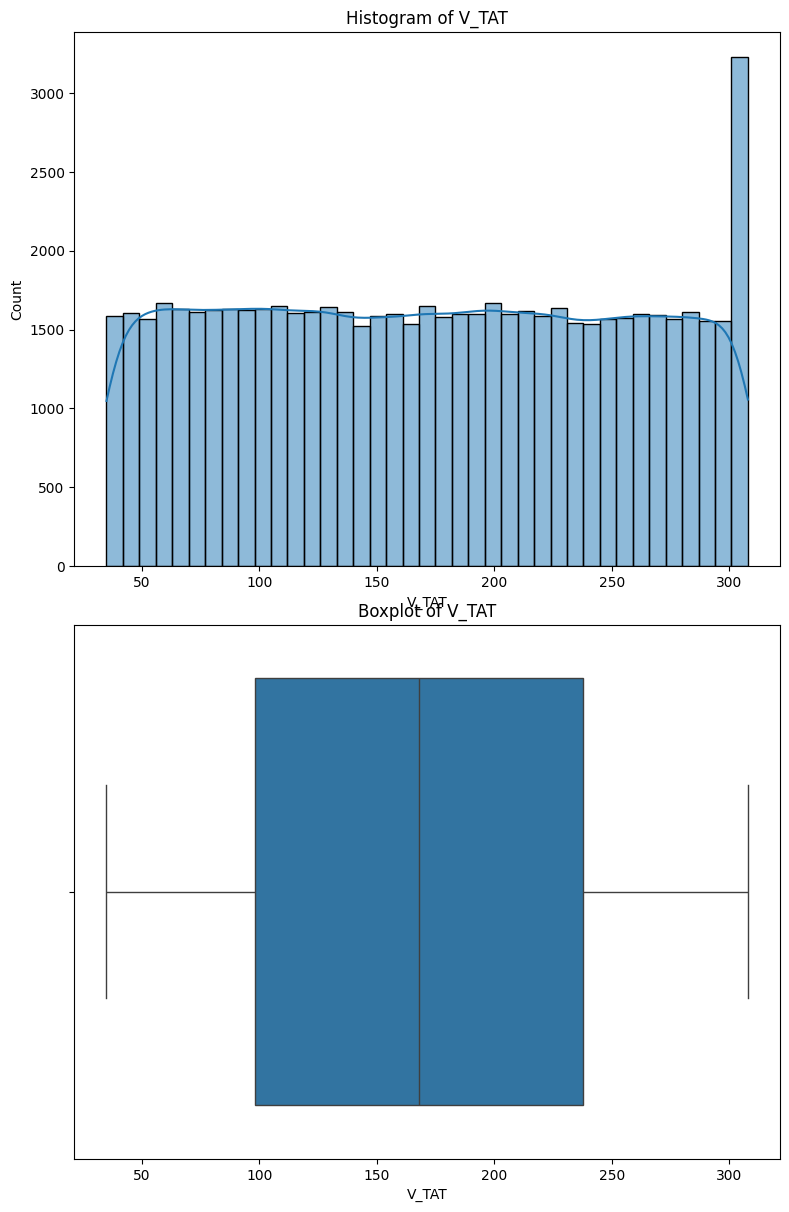

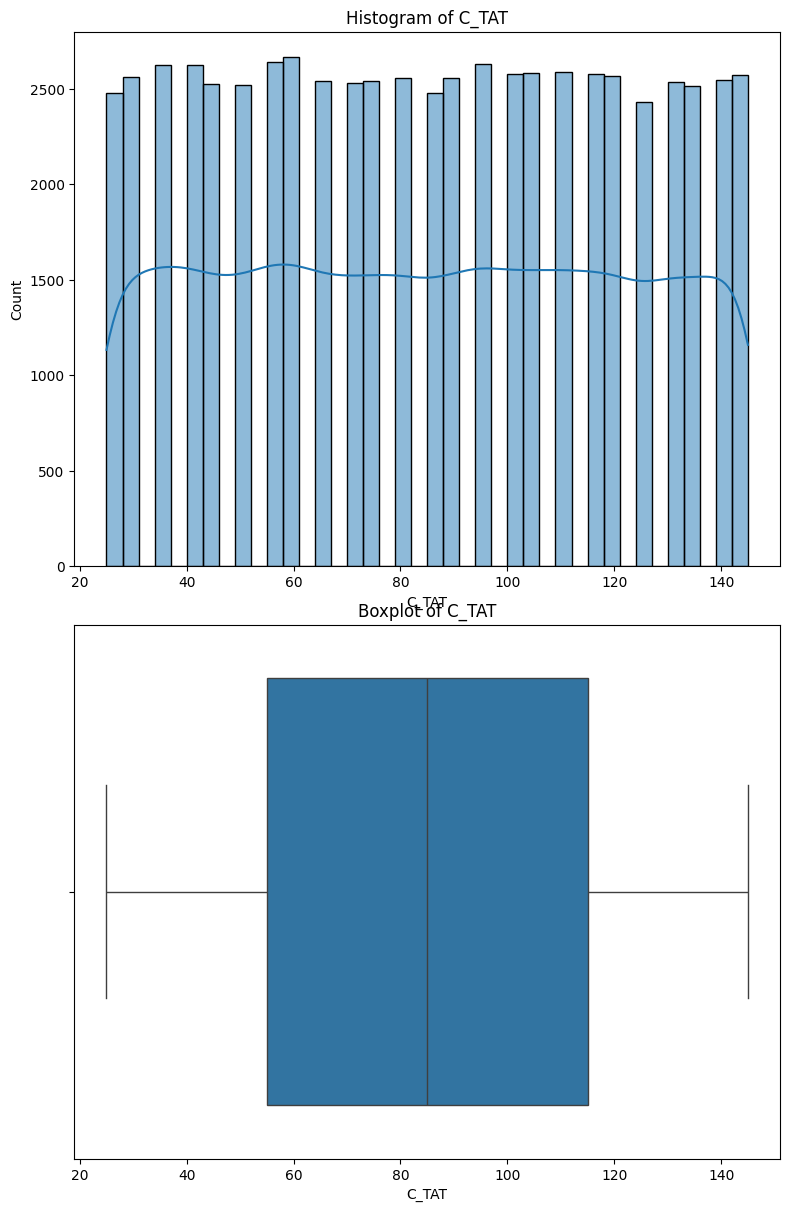

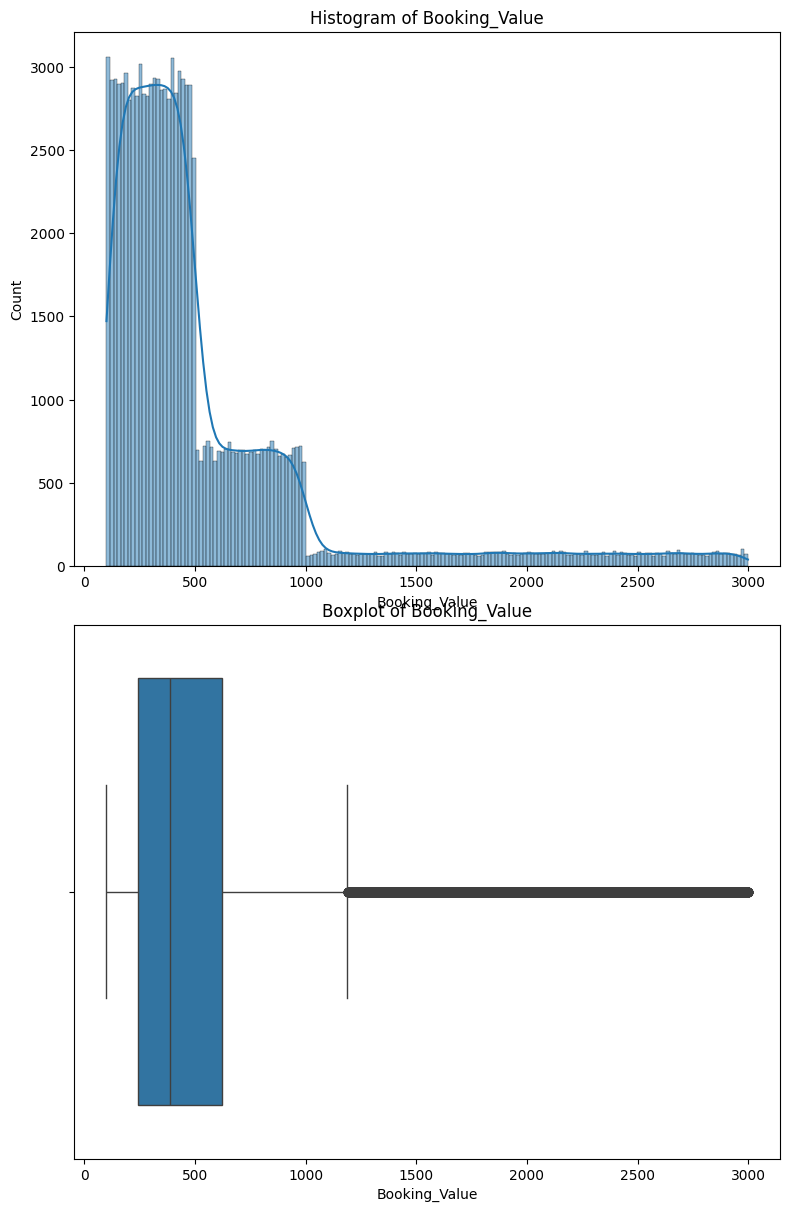

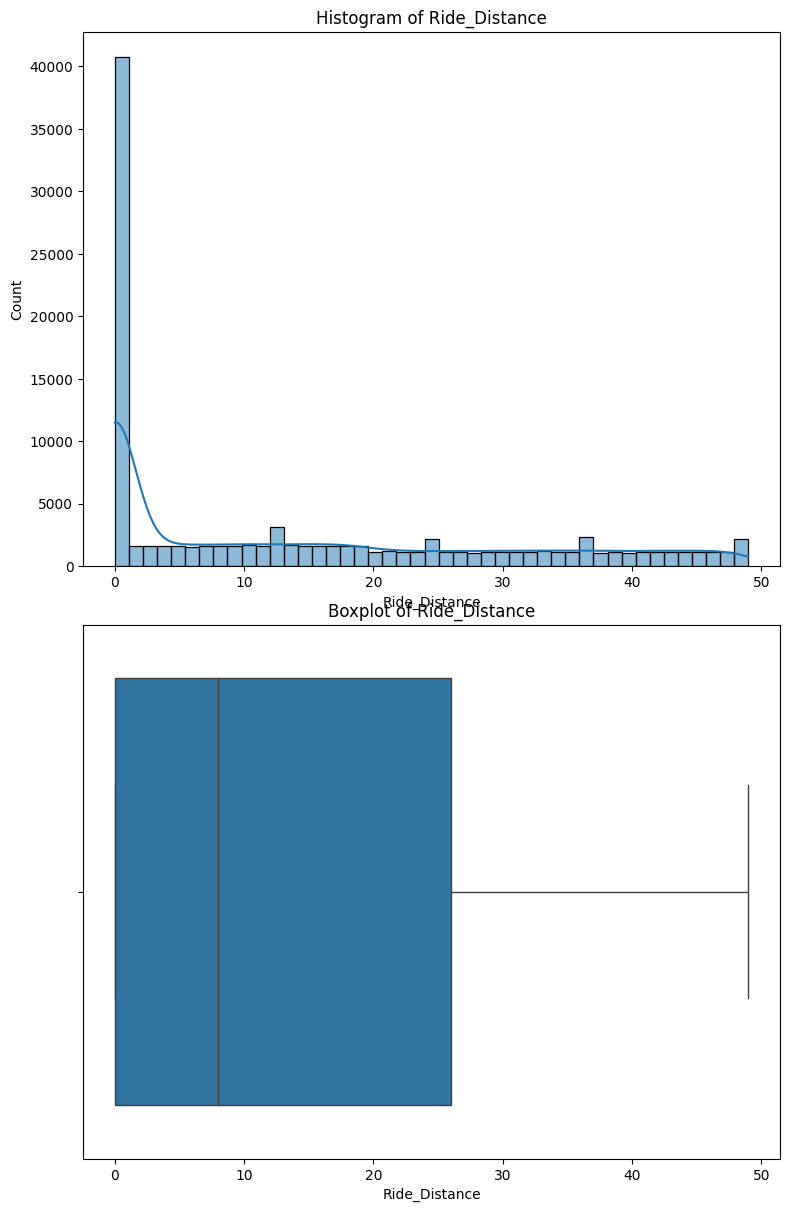

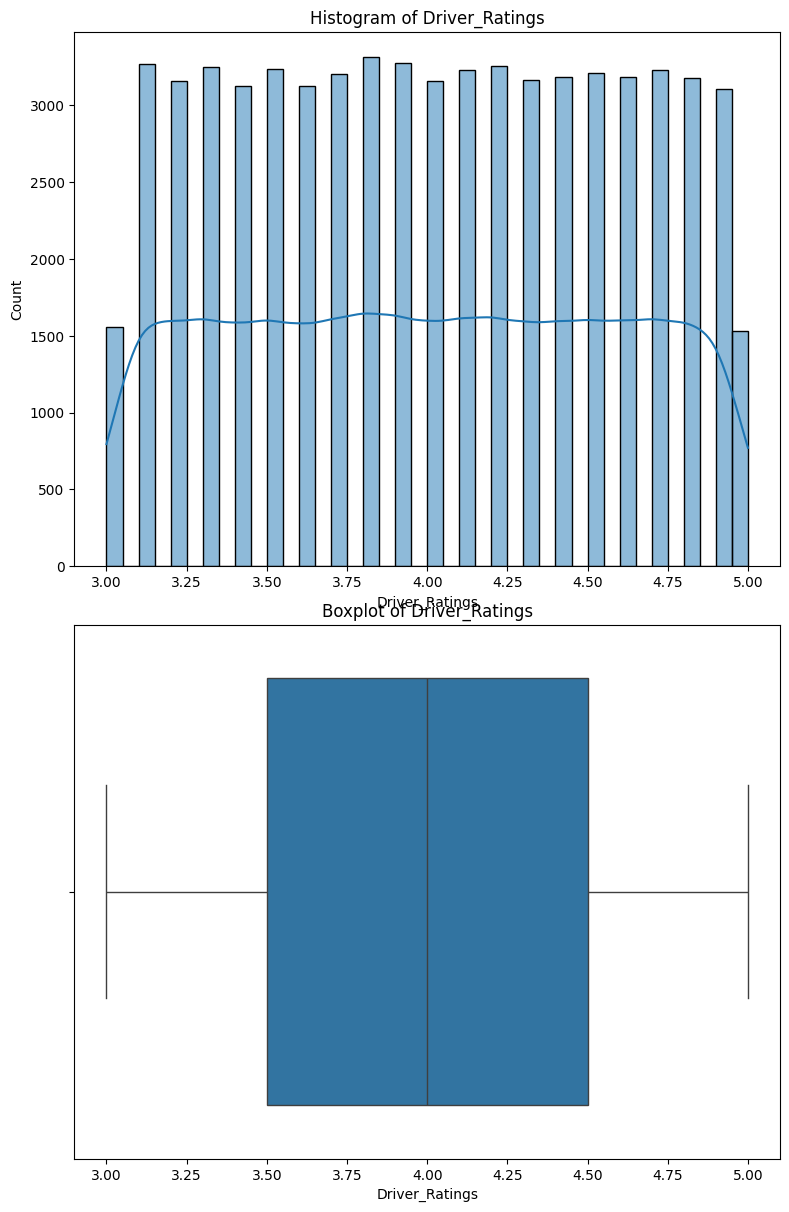

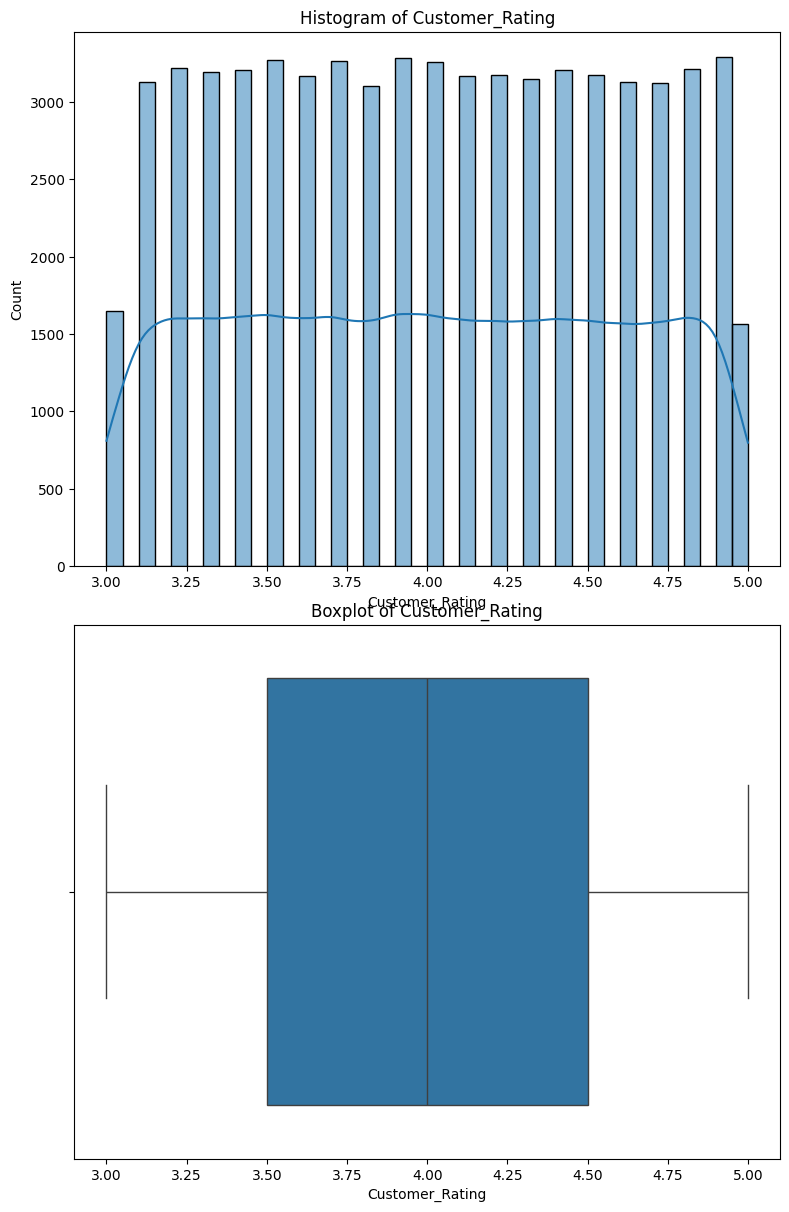

In [26]:
for x in continuos_col:
    fig, ax =plt.subplots(2,1,figsize=(8,12))
    sns.histplot(data=data, x=x, kde=True, ax=ax[0])
    sns.boxplot(data=data, x=x, ax=ax[1])
    plt.tight_layout()
    ax[0].set_title(f'Histogram of {x}')
    ax[1].set_title(f'Boxplot of {x}')
    plt.show()


---
1. Around 37.9% of order is not successful, quite high percentage of canceled, which cause revenue loss.

- It should be noted 9.83% of driver not found is an issue need to be solved, as it's not a natural or unavoidable event, and must be solved in order to get back customer satisfaction and improve revenue.

2. From the 10.19% canceled by customer,
- 30.24% of them, around 3100 customers cancel due to driver is not moving towards pickup location
- 25.43% of them being asked by driver to cancel the order
- 19.82% of them change of plans
- 14.93% of them due to AC is not working
- 9.57% due to wrong address

We observe, that reason 1 and 2 is due to driver mistakes, whether it doesn't go towards pick up location, ask customer to cancel the orders, it is account for around 55.67% (30.24% + 25.43%), which means more than half customers who canceled the trip is due to drivers problem.

In addition, 14.93% of canceled orders by customer is due to AC not working, which means drivers' car issue again.

The rest reasons of canceled orders by customers are due to change of plans or wrong address. If it's really the issue, we can consider improve the app, allow changing of address to minimise cancellation.

3. From 17.89% canceled by drivers, 
- 35.49% of them (around 6.2k), is due to personal and car related issue
- 29.36% due to customer related issue
- 19.82% due to customer was coughing or sick
- 15.32% due to more than permitted people in there
  
Driver personal and car related issue is again a problem. Indeed some personal issue is unavoidable, however some car related issue is again related to why customer cancel the order, which is due to AC is not working, which actually point out possible problem, which is drivers car problem.

15.32% of drivers has canceled the order due to more people than allowed, hence we could consider to make number of people allowed for each ride more visibile on our app.

4. 6.14% is incomplete rides. These mainly driven by customer demand and vehicle breakdown (around 40% respectively). Again, the vehicle breakdown is an issue.

5. Most of customers pay using cash, followed by UPI (digital payments).
6. The bookings are high at 12 noon, followed by 3pm and 8 AM. While the lowest is around 6PM night.

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


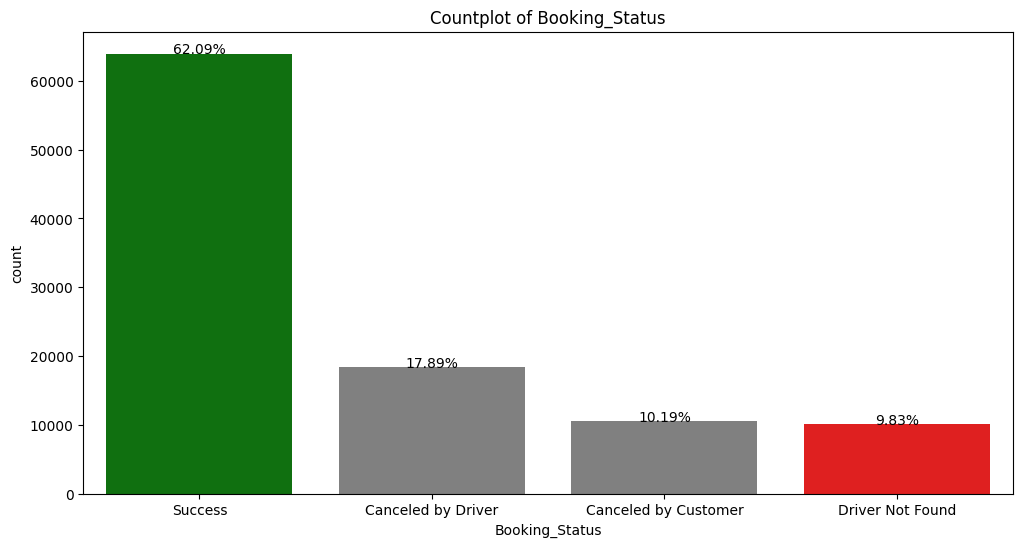

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


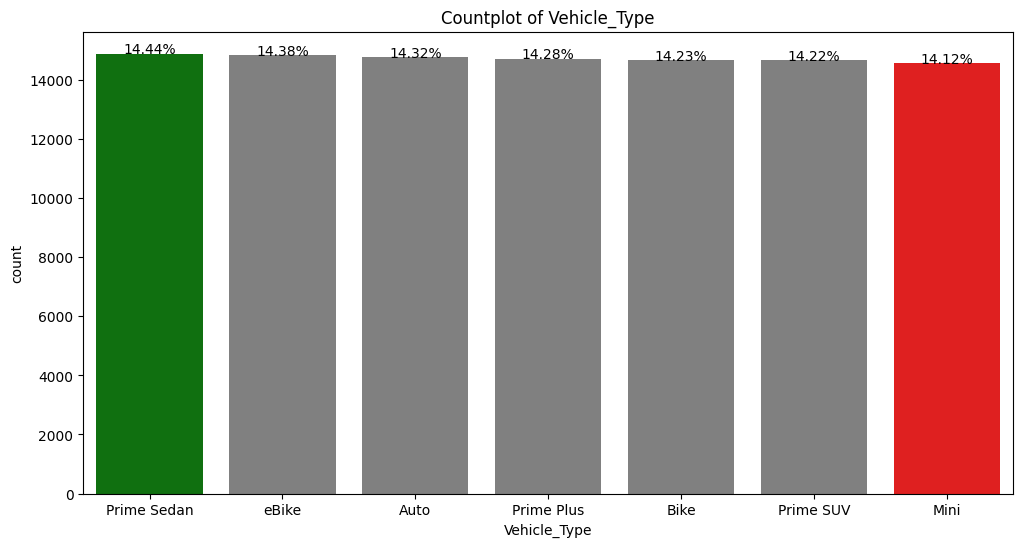

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


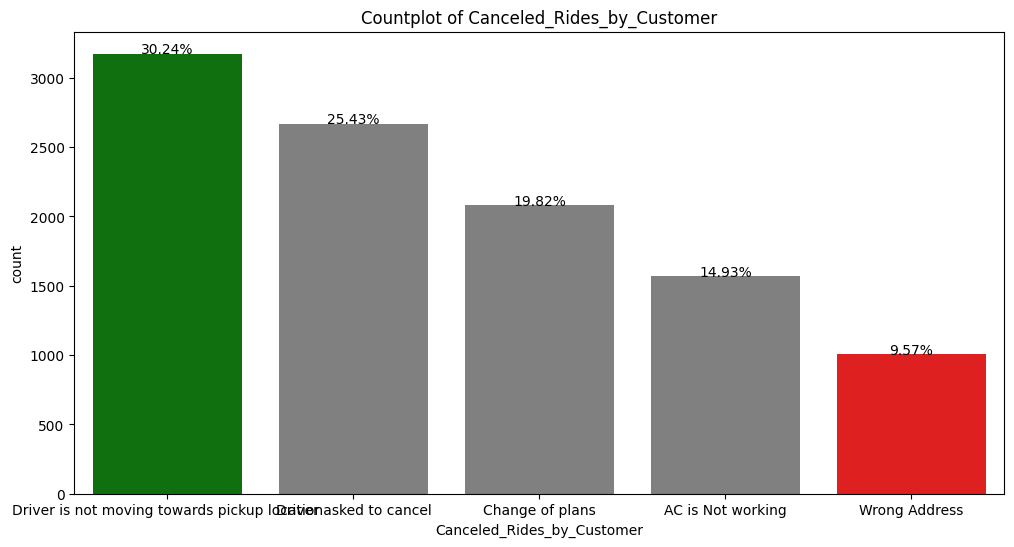

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


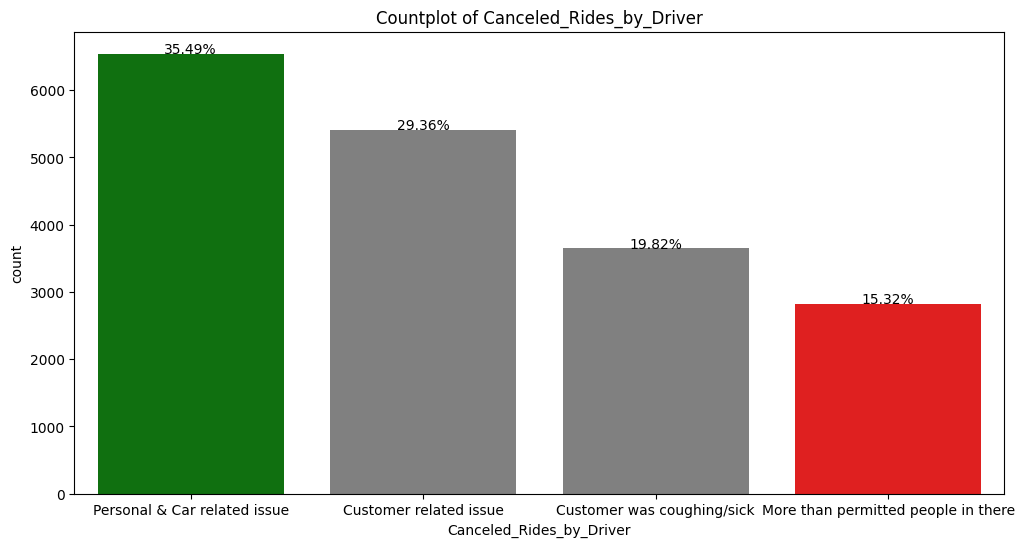

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


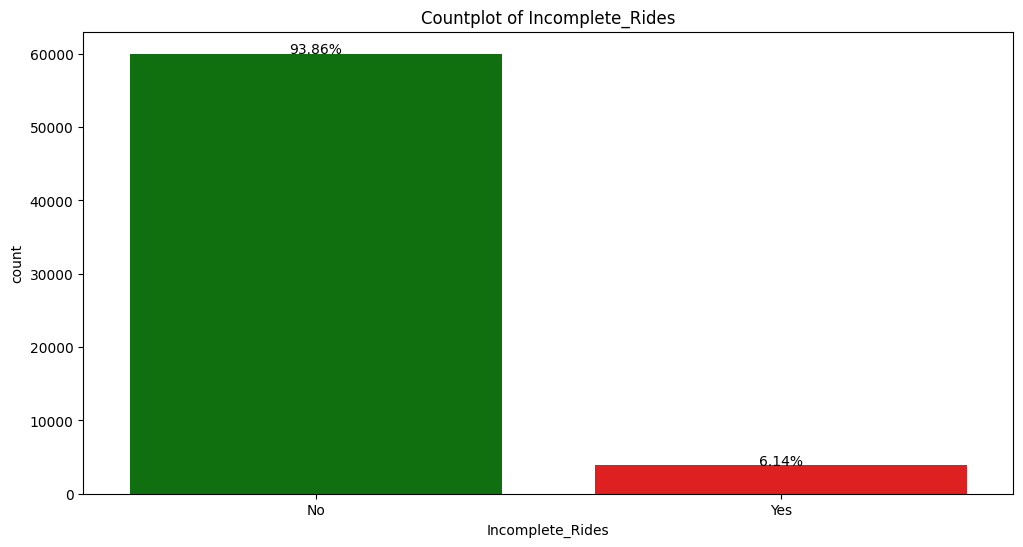

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


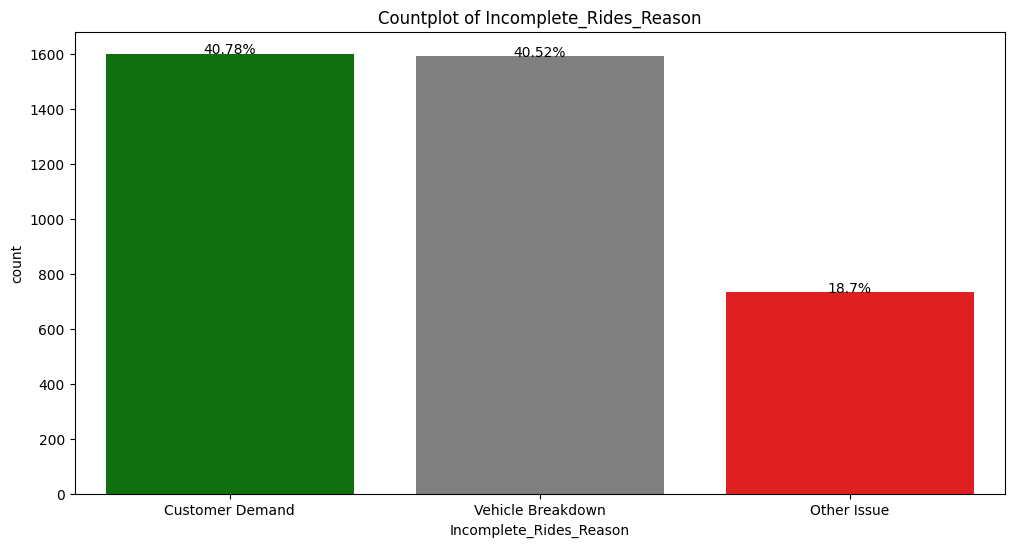

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


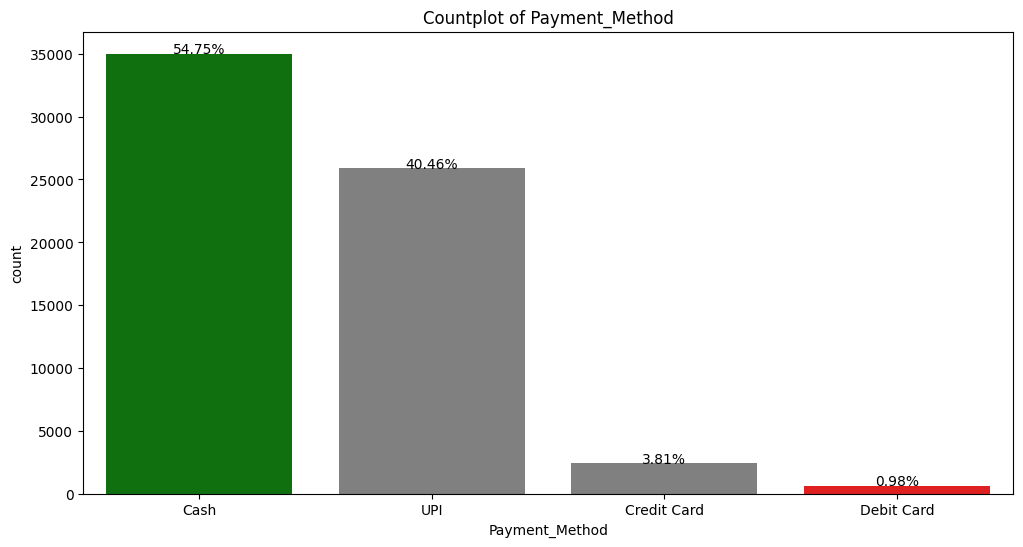

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


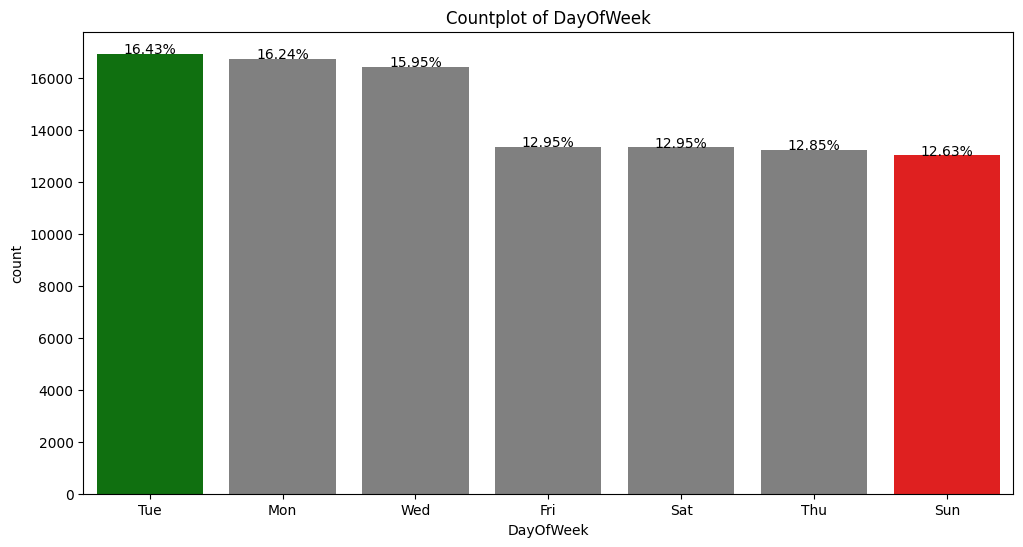

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


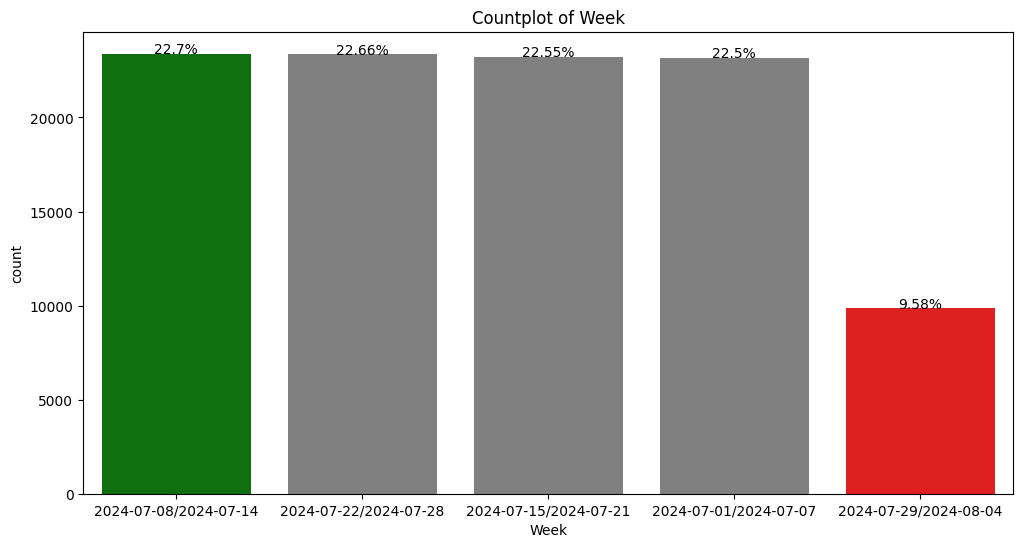

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


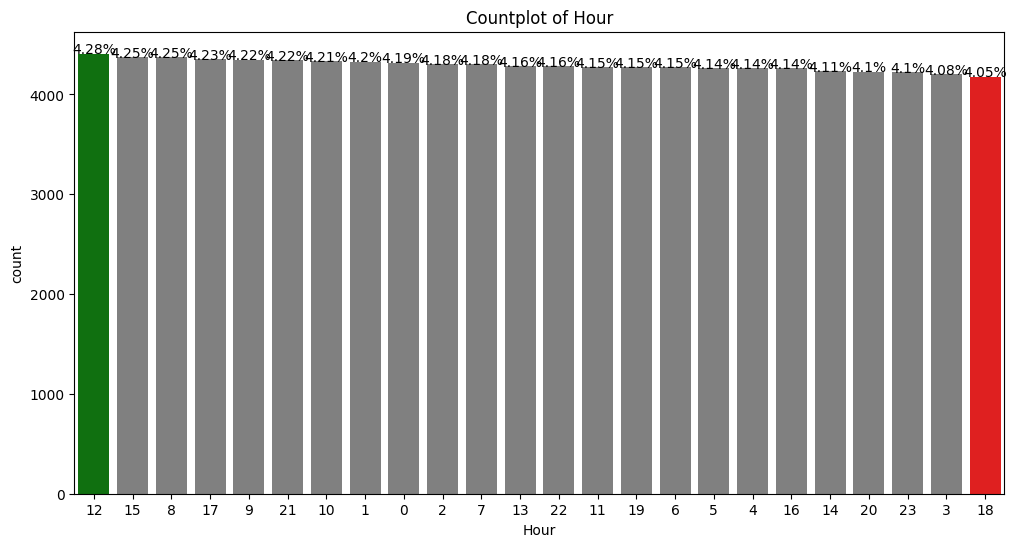

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


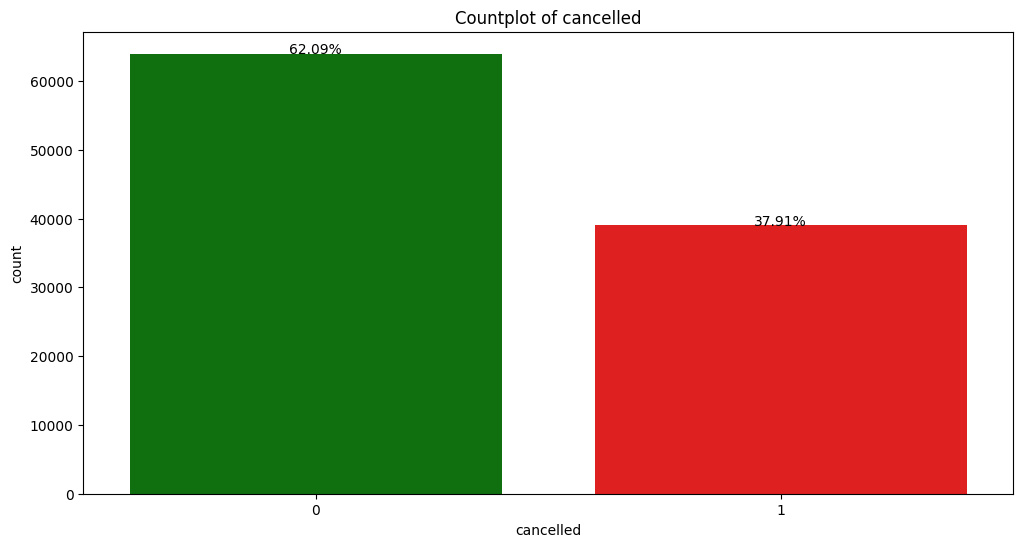

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\1620956794.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )


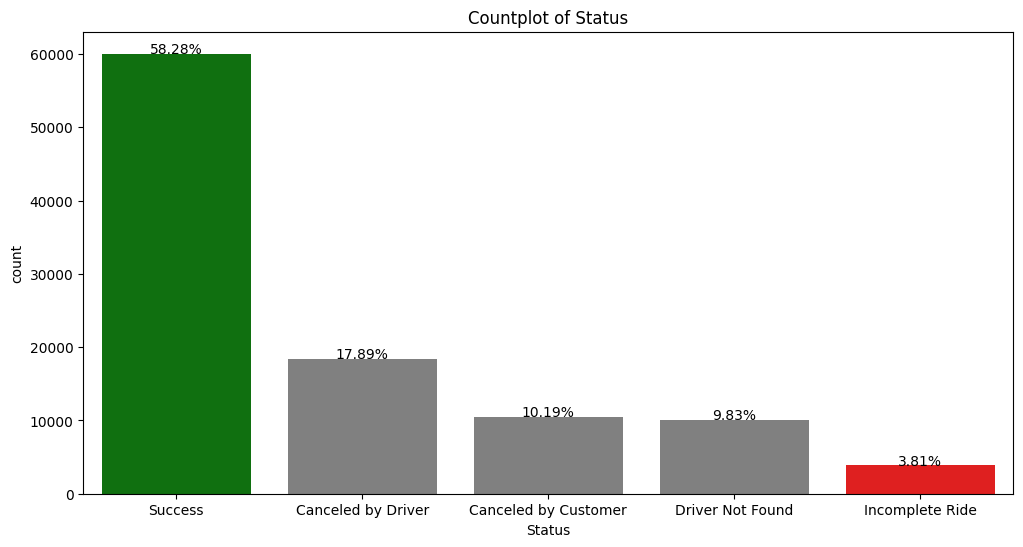

In [28]:
for x in grouping:
    df= data[x].value_counts(normalize=True).mul(100).round(2)
    plt.figure(figsize=(12,6))
    colors=(['green']+['grey']*(len(df)-2)+['red'])
    ax=sns.countplot(data=data, x=x,order=df.index, palette=colors )
    for p, percentage in zip(ax.patches, df):
        ax.annotate(f'{percentage}%', (p.get_x()+p.get_width()/2, p.get_height()), ha='center')
    
    plt.title(f'Countplot of {x}')
    plt.show()

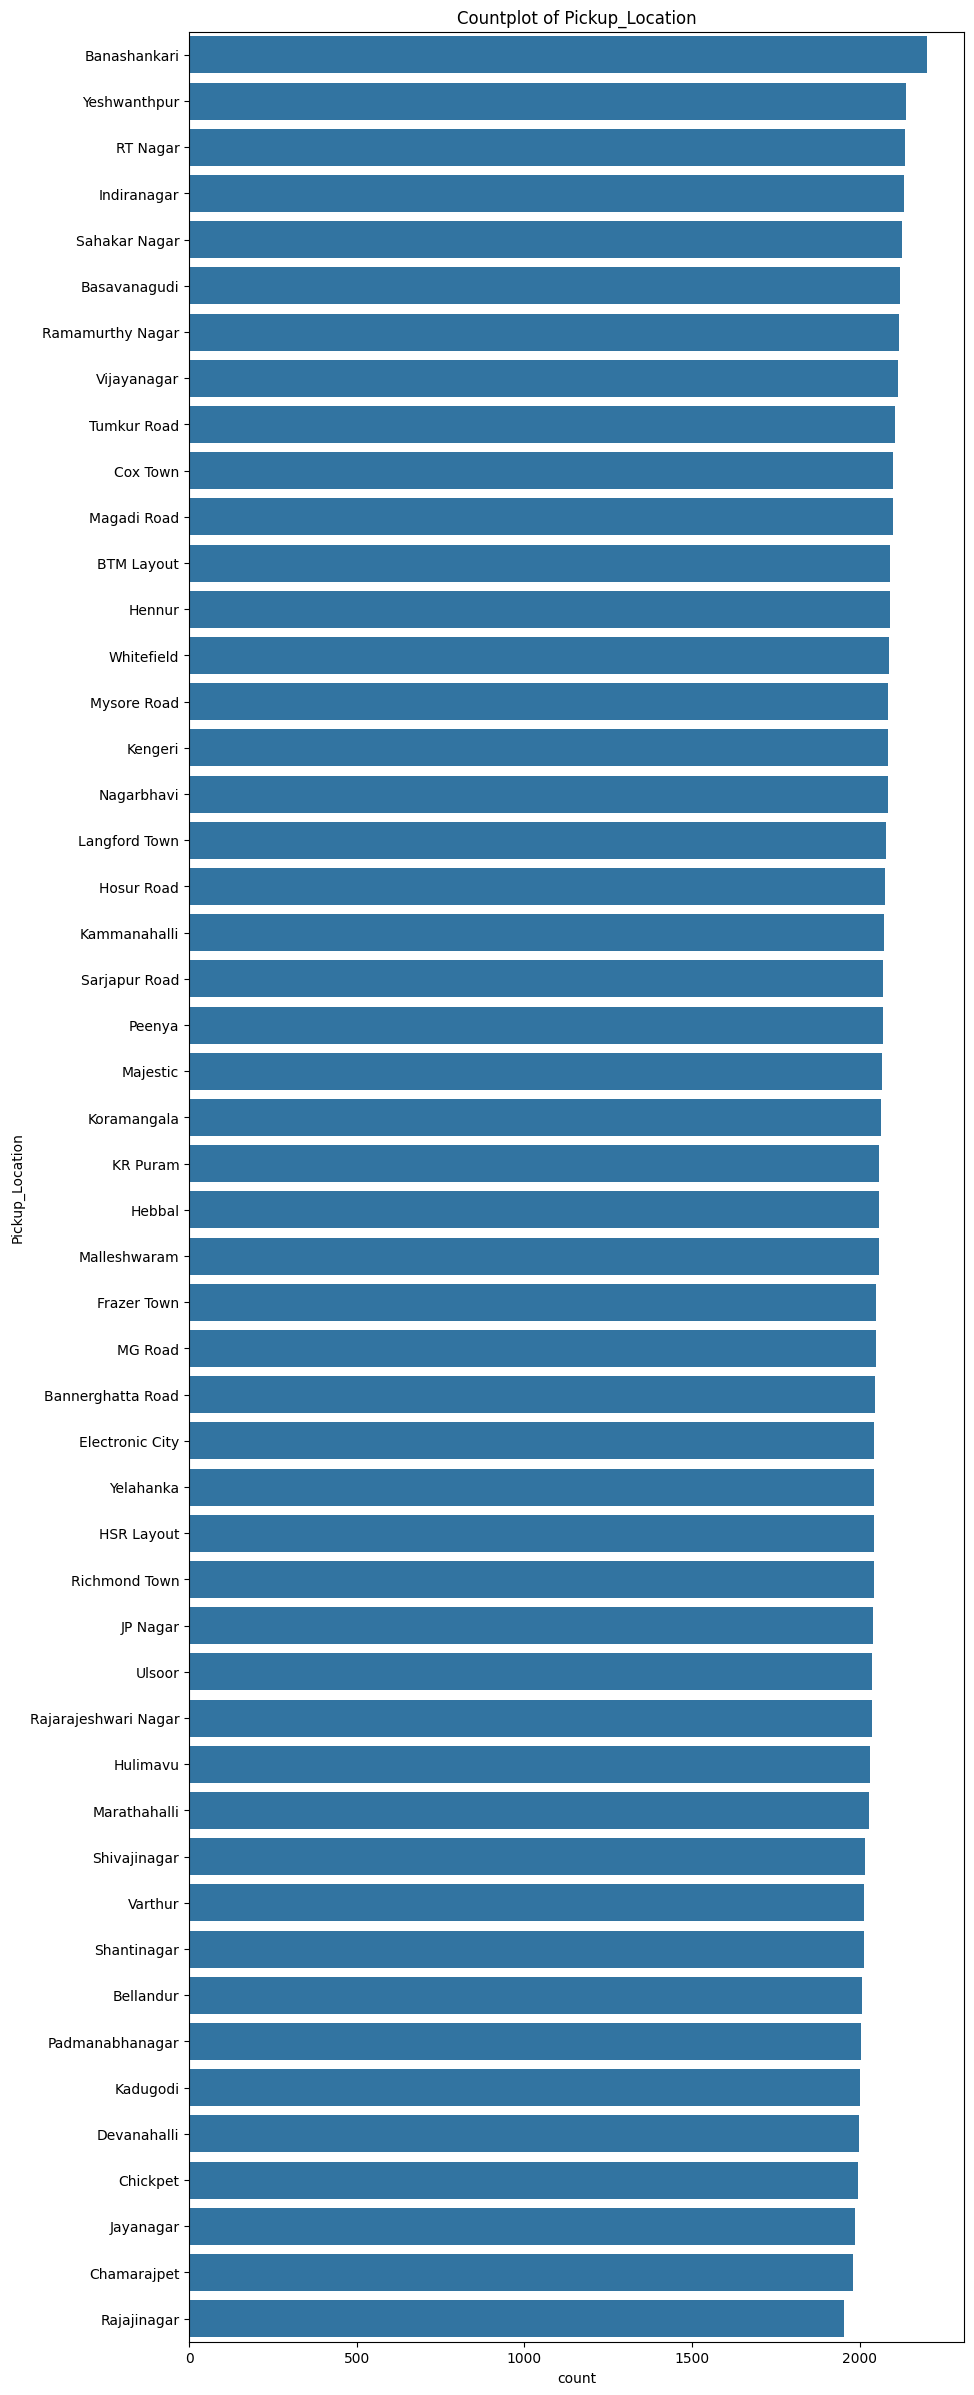

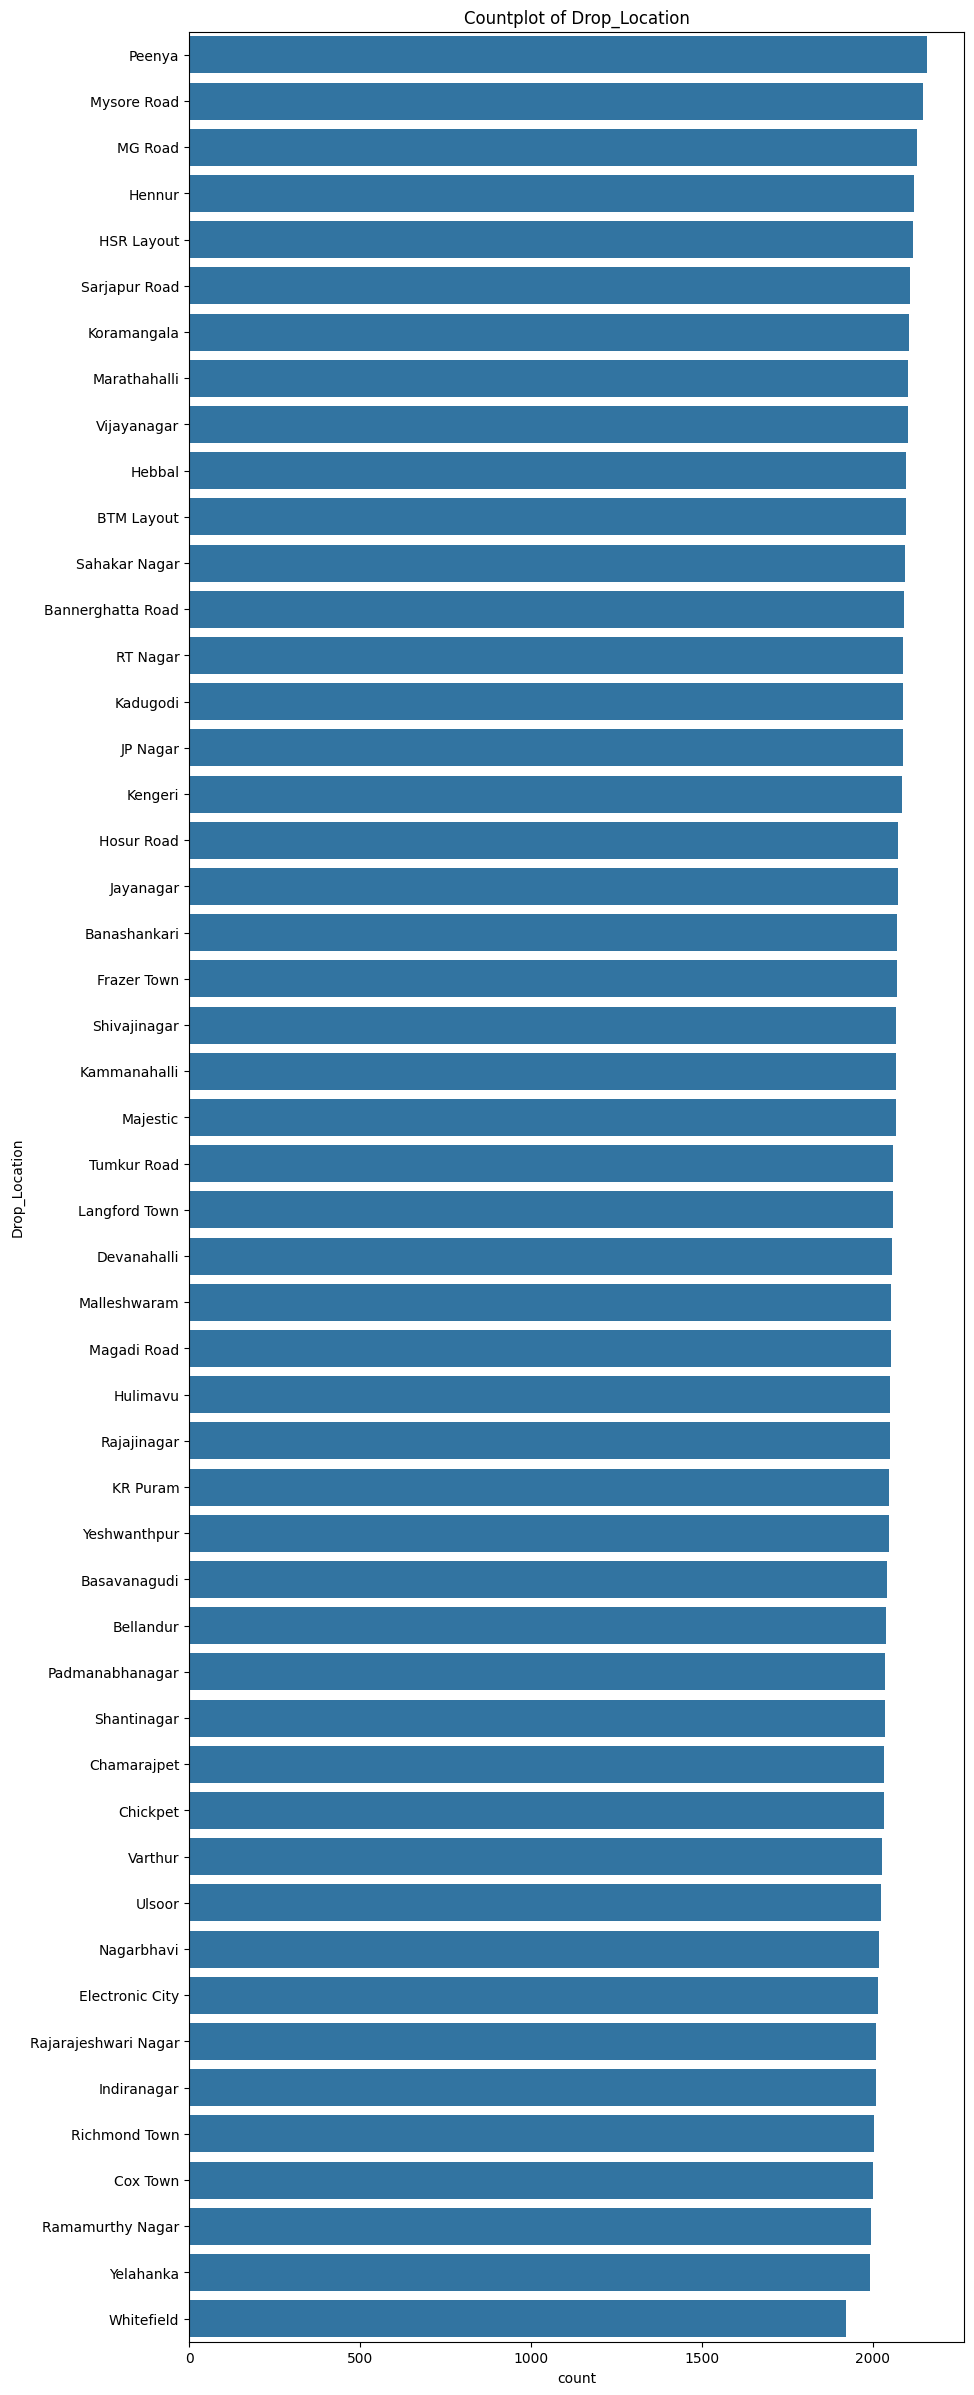

In [29]:
for y in ['Pickup_Location', 'Drop_Location']:
    plt.figure(figsize=(10,30))
    location_order = data[y].value_counts().index
    sns.countplot(data=data, y=y,order=location_order)
    plt.title(f'Countplot of {y}')
    plt.show()

#it seems not much different for amount of bookings by location

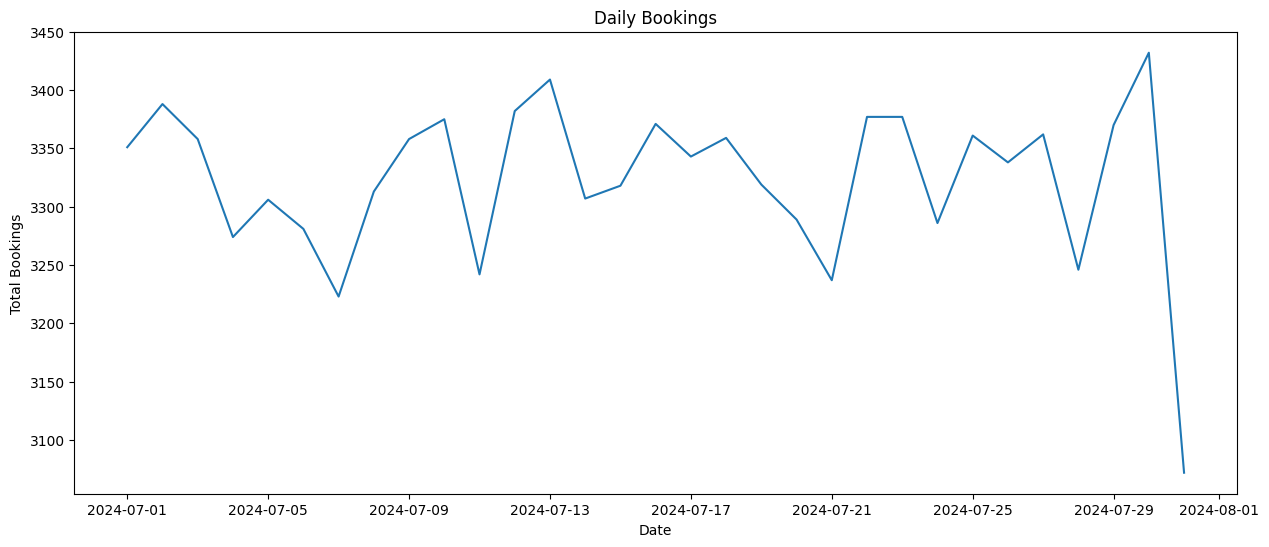

In [30]:
# Daily bookings
daily_bookings= data.groupby('Date')['Booking_ID'].count().reset_index()
plt.figure(figsize = (15,6))
sns.lineplot(data=daily_bookings, x='Date', y='Booking_ID')
plt.title('Daily Bookings')
plt.xlabel('Date')
plt.ylabel('Total Bookings')
plt.show()
#it seems there is only 1 month, hence we cannot conclude the monthly trend or sesoanality.

### Choosing an Appropriate Comparison Metric

Raw booking counts will not be used as the primary metric when comparing days of the week.

This is because the dataset does not contain an equal number of observations for each weekday. The dataset ends on 31 July 2024, which falls on a Wednesday. As a result, Monday, Tuesday, and Wednesday appear more frequently in the dataset than Thursday, Friday, Saturday, and Sunday.

Using total booking counts may therefore lead to misleading conclusions, as higher volumes could simply reflect a greater number of observed days rather than stronger booking activity.

To ensure fair comparisons, **normalized metrics such as average bookings per day or cancellation rates** will be used where appropriate.


In [32]:
# We will not used this 'sum' or 'count' as metrics
# This due to e.g. Mon Tue Wed have higher total bookings amount compared to Thu Fri Sat Sun not because they perform well, it just due to different number of day of week appears in that month
# E.g. The dataset ends at around 31 July 2024. It's ends at Wed. This means Mon Tue Wed appears more time compared to the rest of the day, hence using total is not a fair metrics
data.groupby('DayOfWeek').size().reset_index(name='Count')

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\2609869746.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('DayOfWeek').size().reset_index(name='Count')


,DayOfWeek,Count
0,Mon,16729
1,Tue,16926
2,Wed,16434
3,Thu,13236
4,Fri,13345
5,Sat,13341
6,Sun,13013


In [33]:
# We want to understand the weekly number of bookings trends
weekly_trend_book=data.groupby(['Week','DayOfWeek']).size().reset_index(name='Book')
weekly_trend_book=weekly_trend_book[weekly_trend_book['Book'] !=0]
weekly_trend_book.groupby('DayOfWeek')['Book'].mean().reset_index()
# 1.Instead of high on Mon Tue Wed that shown by total bookings, we found Sun has the lowest average bookings, followed by Wed
# 2.Tues has highest average bookings
# We should questioned how does average of bookings are lower on Sun when it's a weekends? and why Tue that's weekday has higher average booking compared to the rest of the day?


C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\877035637.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_trend_book=data.groupby(['Week','DayOfWeek']).size().reset_index(name='Book')
C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\877035637.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_trend_book.groupby('DayOfWeek')['Book'].mean().reset_index()


,DayOfWeek,Book
0,Mon,3345.80
1,Tue,3385.20
2,Wed,3286.80
3,Thu,3309.00
4,Fri,3336.25
5,Sat,3335.25
6,Sun,3253.25


In [34]:
#At 12 noon, it seems the number of bookings are at peak. However, we should conclude with cautious, as here the average bookings are roughly similar, and around 600 bookings and not much differ.
week_hour=data.groupby(['DayOfWeek','Hour']).size().reset_index(name='Book')
week_hour.groupby('Hour')['Book'].mean().reset_index()

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\3649171152.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  week_hour=data.groupby(['DayOfWeek','Hour']).size().reset_index(name='Book')


,Hour,Book
0,0,616.857143
1,1,618.428571
2,2,615.000000
3,3,600.142857
4,4,609.000000
5,5,609.142857
6,6,610.142857
7,7,614.857143
8,8,624.857143
9,9,621.000000


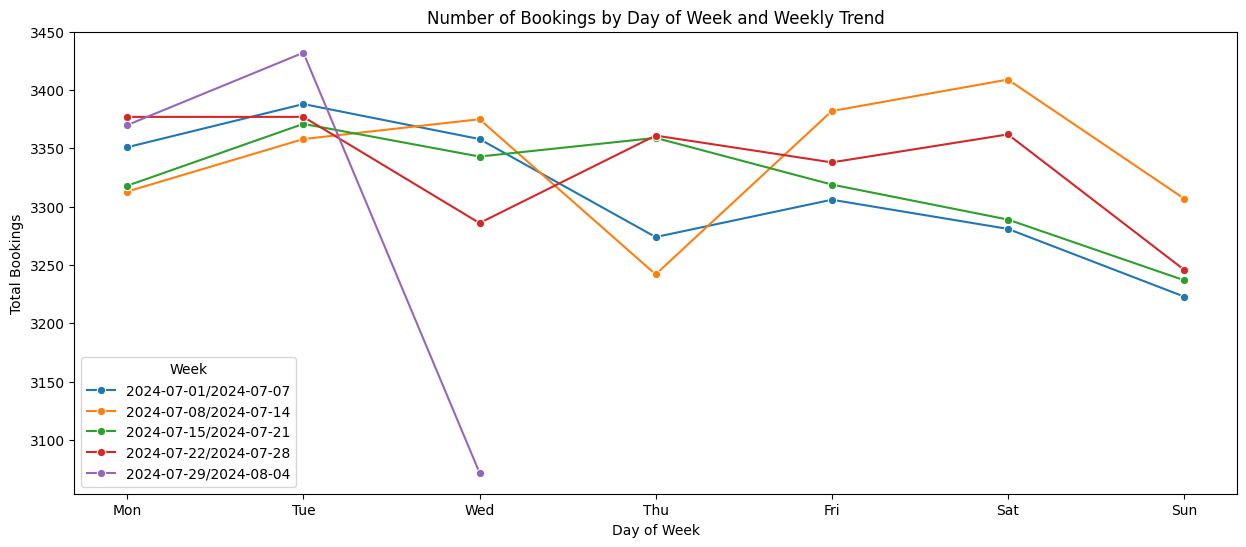

In [35]:
plt.figure(figsize = (15,6))
sns.lineplot(data=weekly_trend_book, x='DayOfWeek', y='Book',hue='Week', marker='o')
plt.title('Number of Bookings by Day of Week and Weekly Trend')
plt.xlabel('Day of Week')
plt.ylabel('Total Bookings')
plt.show()

# Bookings quite stable across week, quite consistent
# It seems Tuesday has slightly higher bookings
# Sunday is the weakest day
# It also weird on wednesday for Week 31, as the bookings number is much lower compared the rest, we might suspect there's missing data or due to the cutoff hour
# week 27 and 28 seems earlier date of month, Tuesday is slightly higher, wednesday quite good, thursday dropped sharply, increases on Friday, drop on Sun
# week 29 an 30, seems closer to end of month, drop on wednesday, increase on thursday, drop on fri, drop on sunday

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\3530525473.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_week=data.groupby(['Week','DayOfWeek','Hour']).size().reset_index(name='Book')
C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\3530525473.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_hour_week=hour_week.groupby(['DayOfWeek','Hour'])['Book'].mean().reset_index(name='Avg_Book')


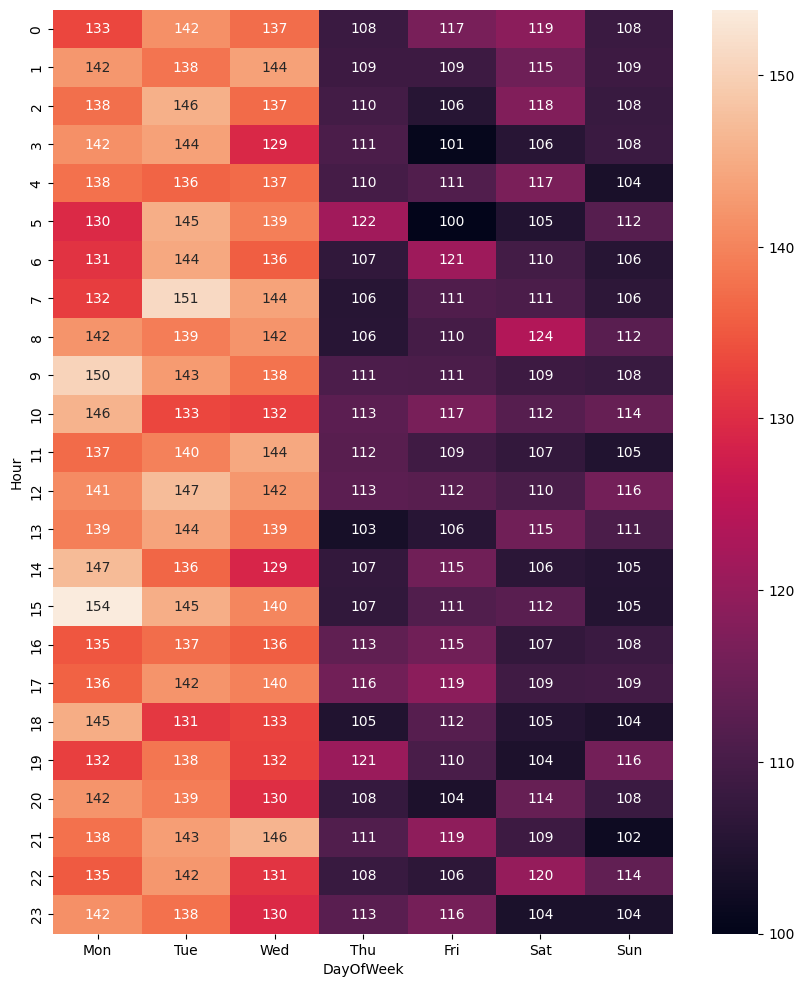

In [36]:
# Heatmap below shows the average bookings by day of week and time of bookings
# It seems  Mon Tue Wed have higher average bookings compared to other days.
hour_week=data.groupby(['Week','DayOfWeek','Hour']).size().reset_index(name='Book')
avg_hour_week=hour_week.groupby(['DayOfWeek','Hour'])['Book'].mean().reset_index(name='Avg_Book')
plt.figure(figsize= (10,12))
sns.heatmap(avg_hour_week.pivot(index='Hour', columns='DayOfWeek', values='Avg_Book'), annot=True, fmt='.0f')
plt.show()

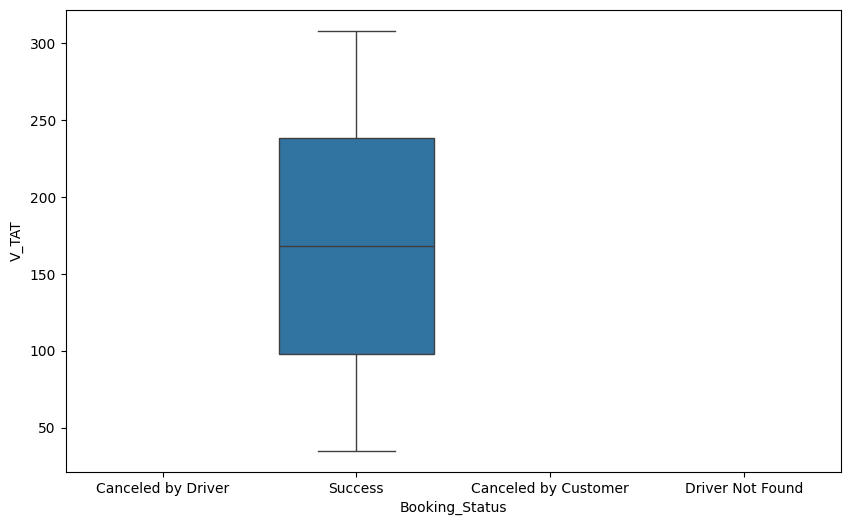

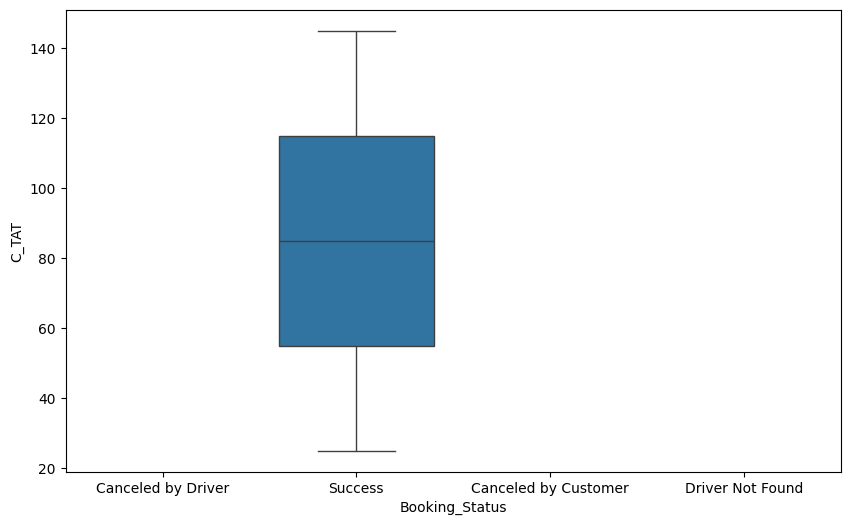

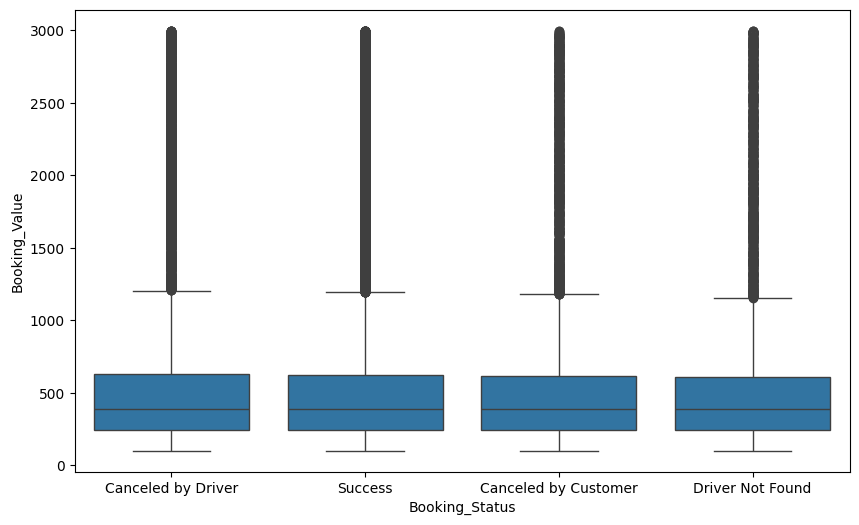

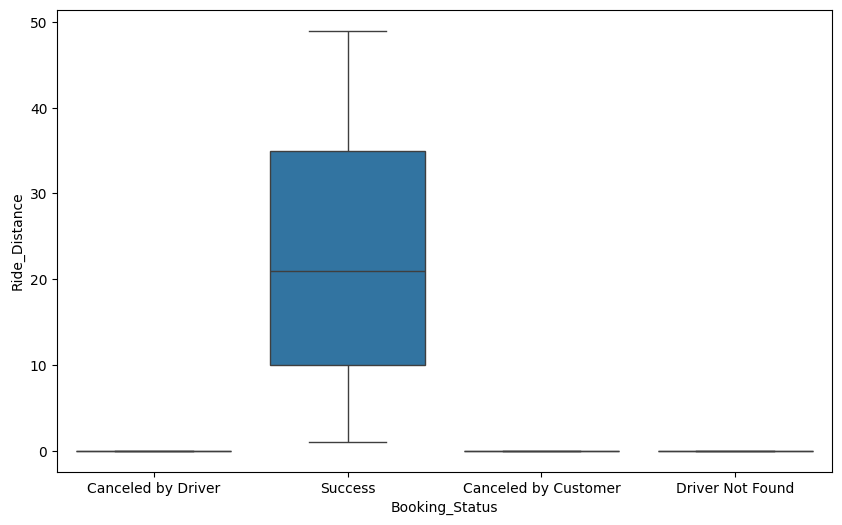

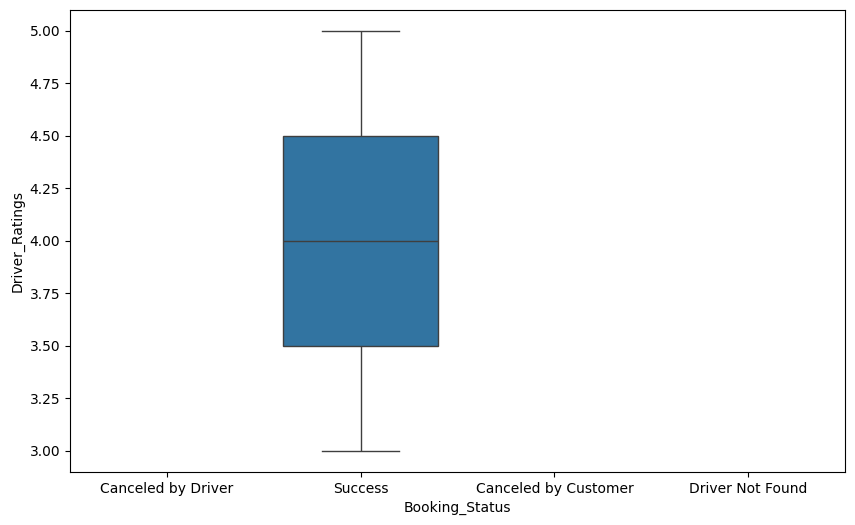

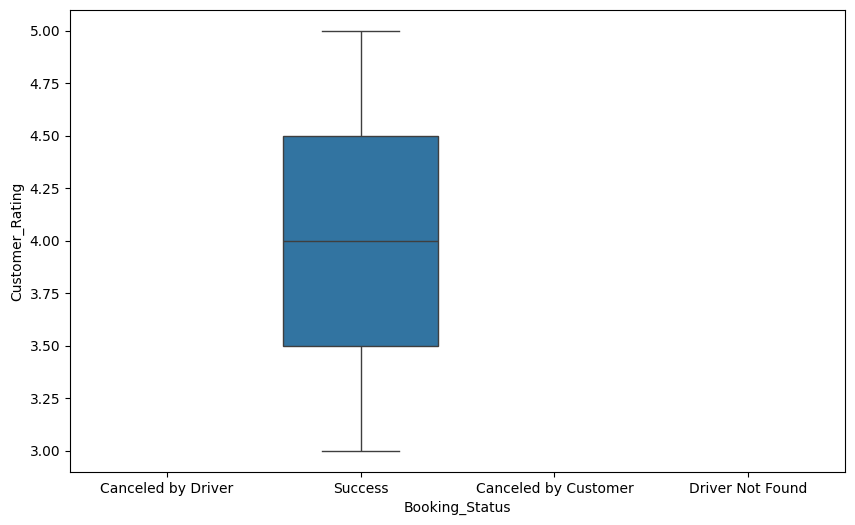

In [37]:
#Not much different
for y in continuos_col:
    plt.figure(figsize= (10,6))
    sns.boxplot(data=data, y=y, x='Booking_Status')
    plt.show()

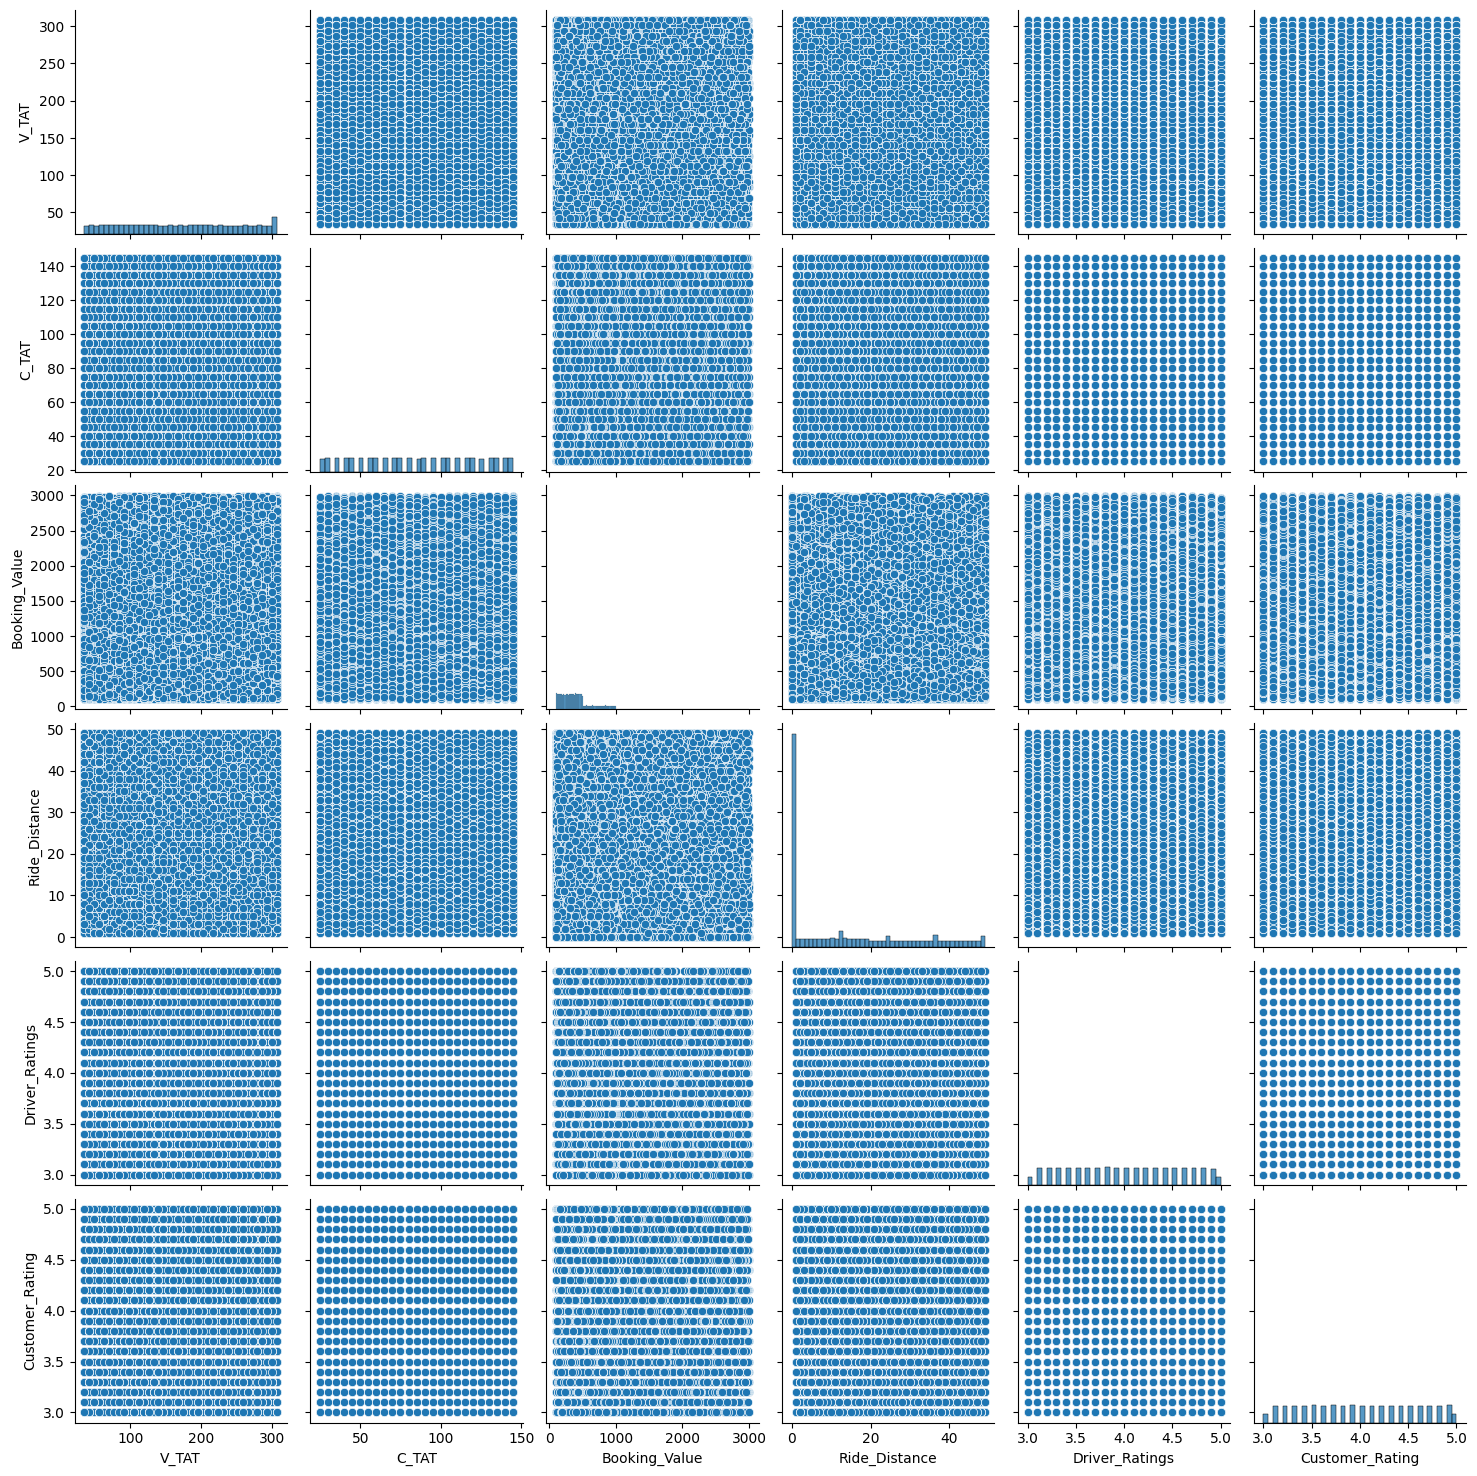

In [38]:
sns.pairplot(data[continuos_col])
plt.show()

<Axes: xlabel='Booking_Value', ylabel='Ride_Distance'>

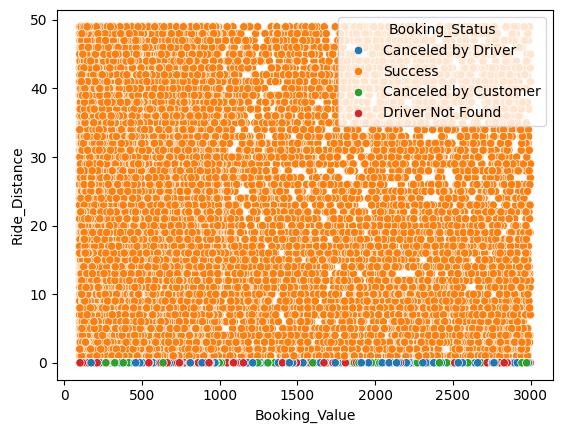

In [39]:
sns.scatterplot(data=data, x='Booking_Value',y='Ride_Distance', hue='Booking_Status')

In [40]:
#Very weak and almost no correlation between continuos variables
data[continuos_col].corr()

,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
V_TAT,1.000000,0.000249,-0.003671,-0.011204,-0.002300,0.000574
C_TAT,0.000249,1.000000,-0.004443,0.000074,-0.002815,0.001015
Booking_Value,-0.003671,-0.004443,1.000000,0.000492,-0.001327,0.006231
Ride_Distance,-0.011204,0.000074,0.000492,1.000000,-0.007235,0.009871
Driver_Ratings,-0.002300,-0.002815,-0.001327,-0.007235,1.000000,-0.002807
Customer_Rating,0.000574,0.001015,0.006231,0.009871,-0.002807,1.000000


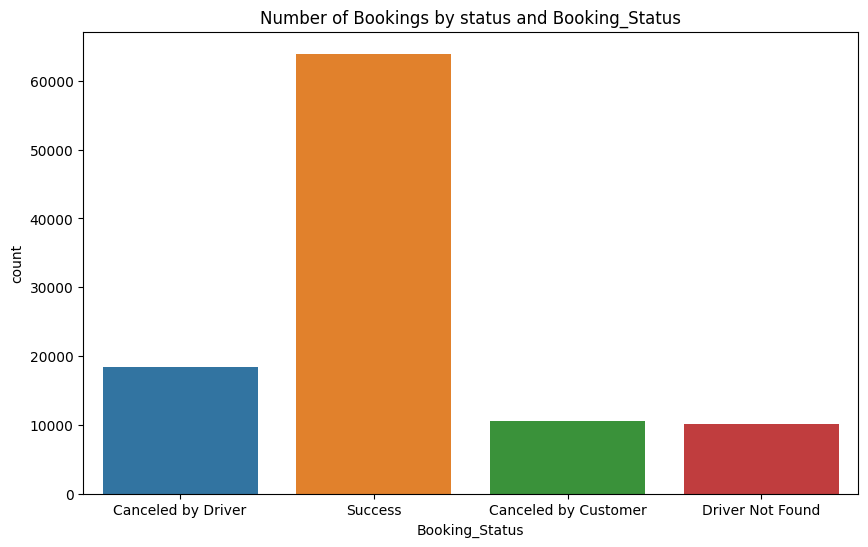

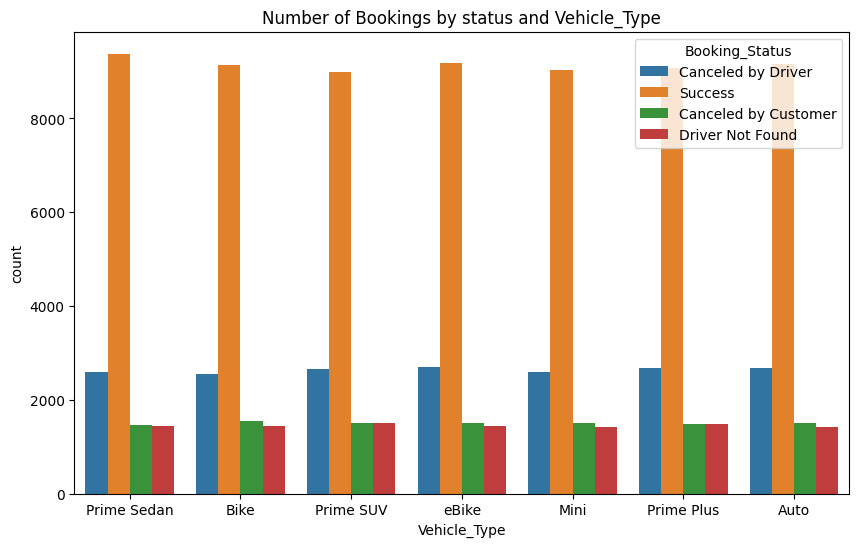

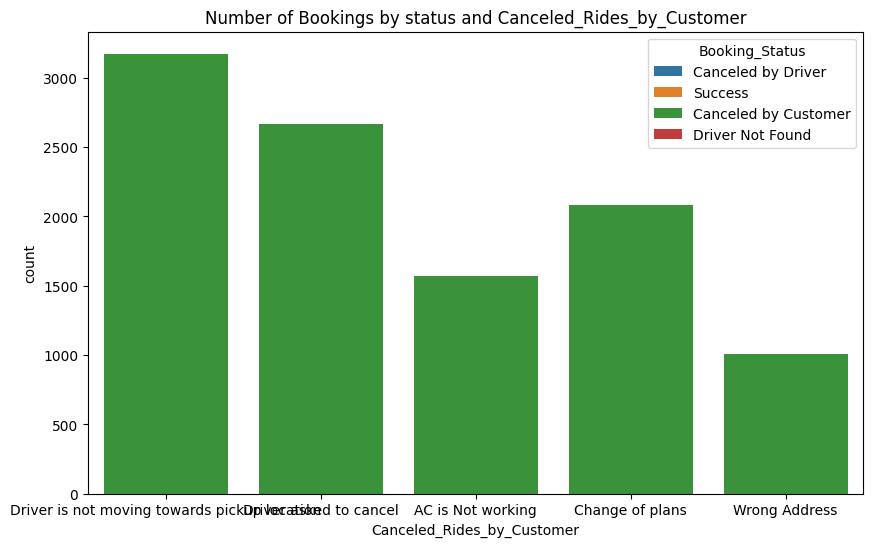

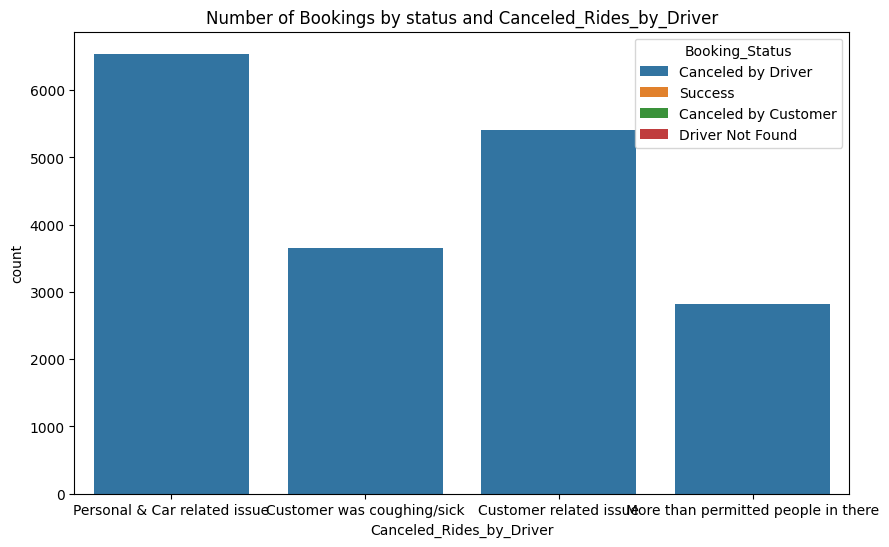

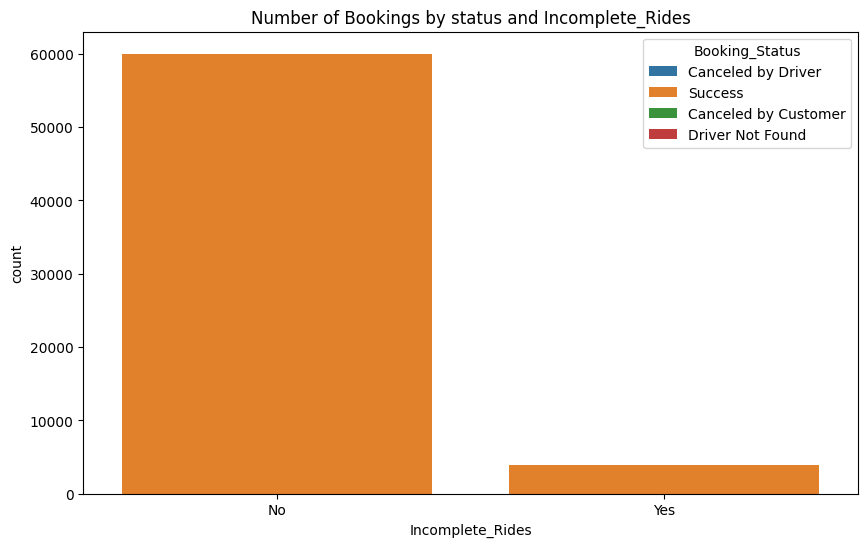

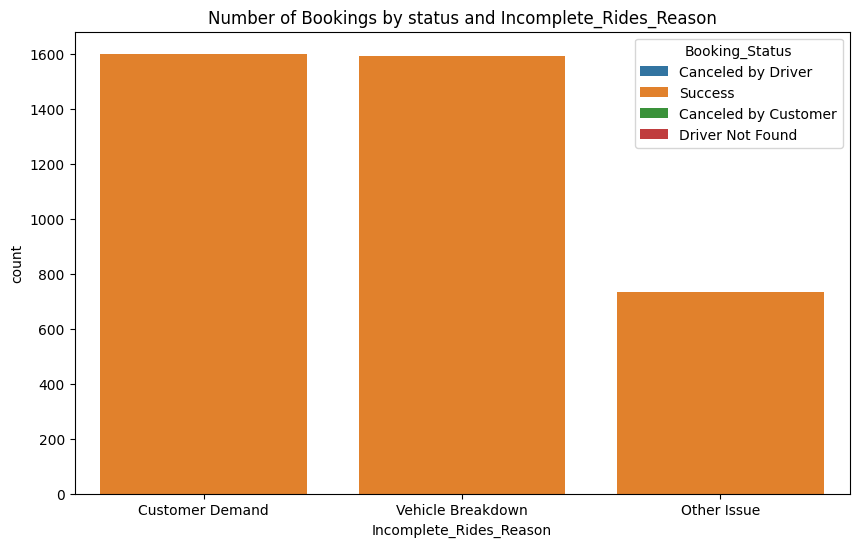

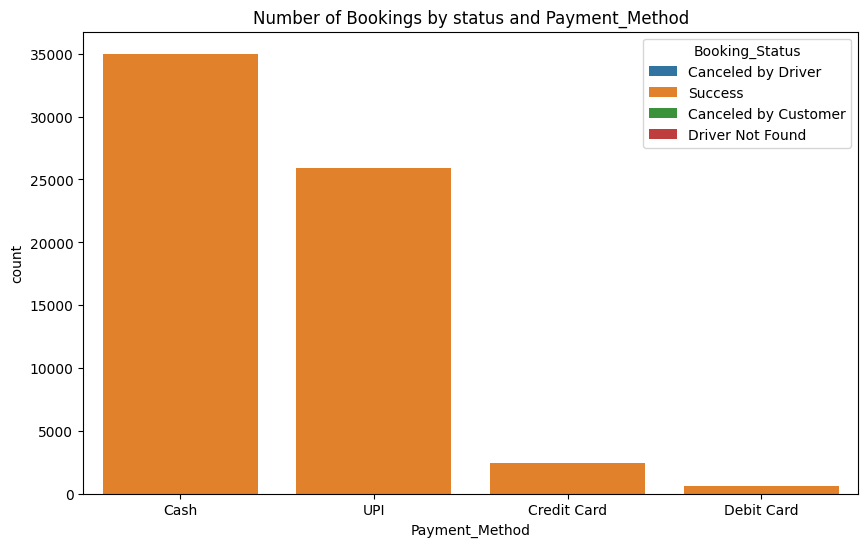

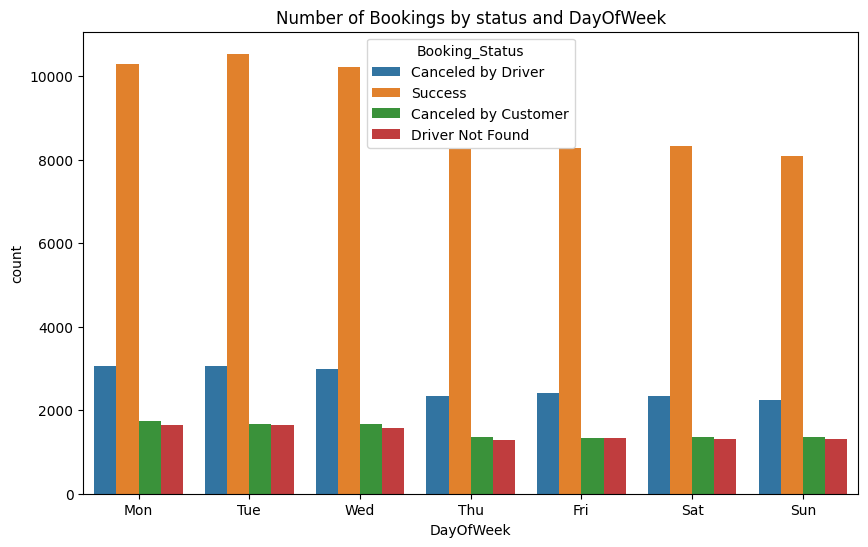

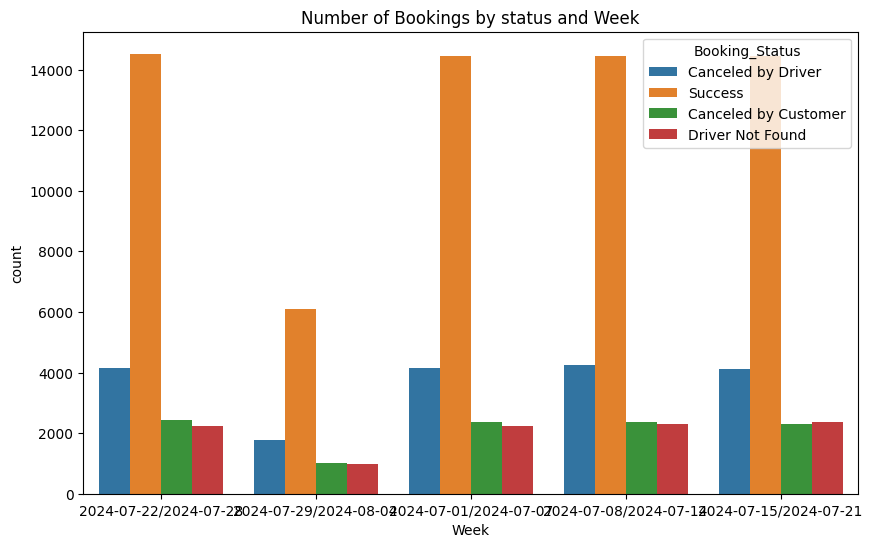

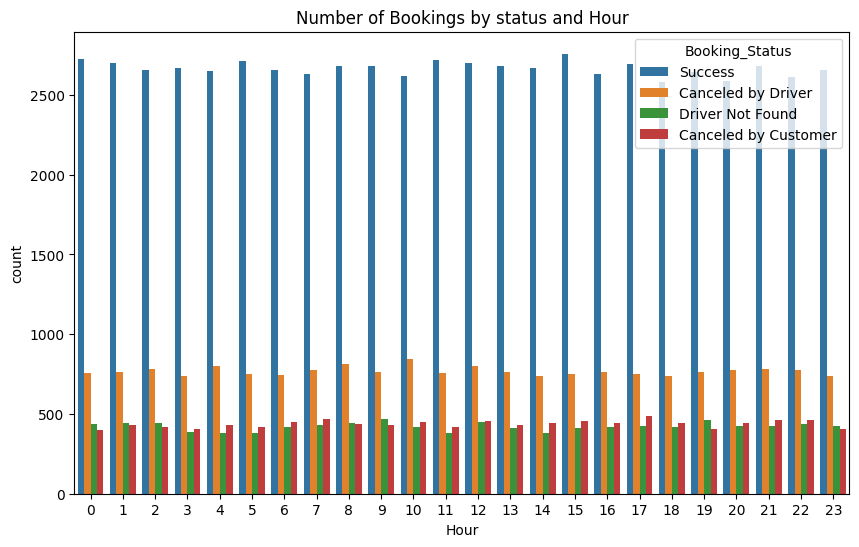

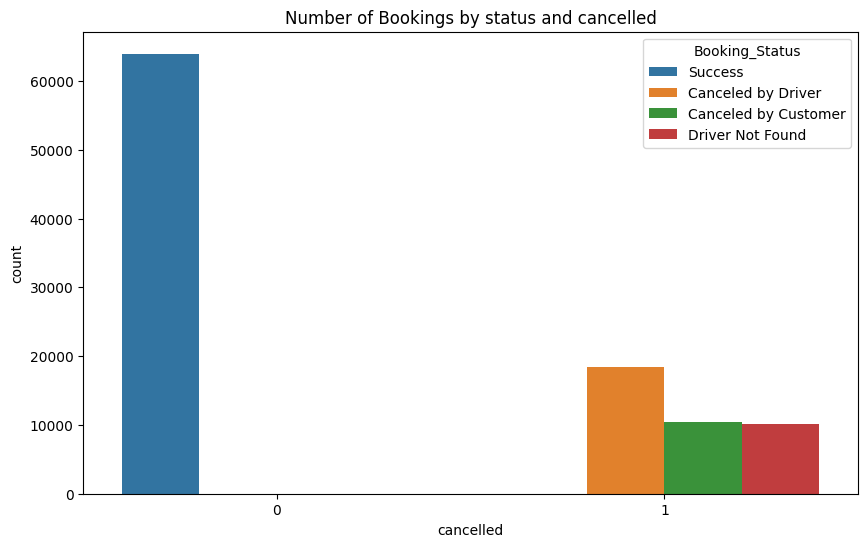

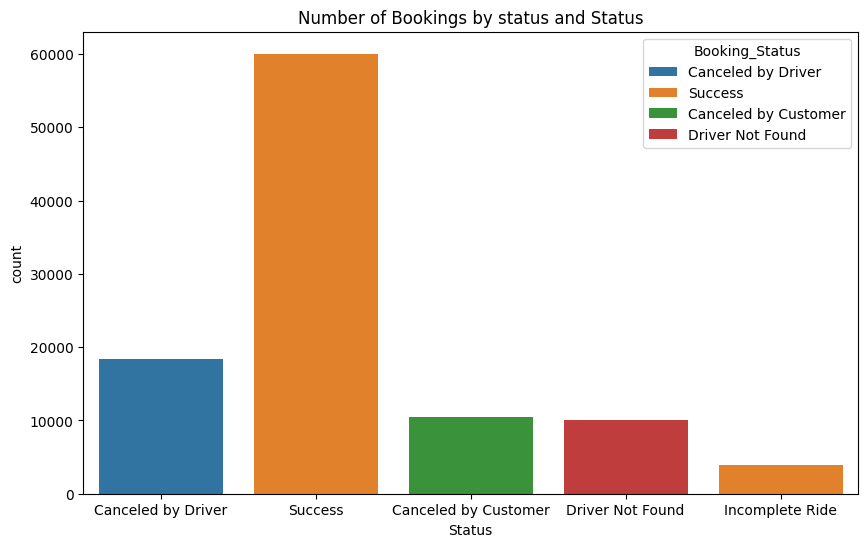

In [41]:
for x in grouping:
    plt.figure(figsize= (10,6))
    sns.countplot(data=data, x=x, hue='Booking_Status')
    plt.title(f'Number of Bookings by status and {x}')
    plt.show()

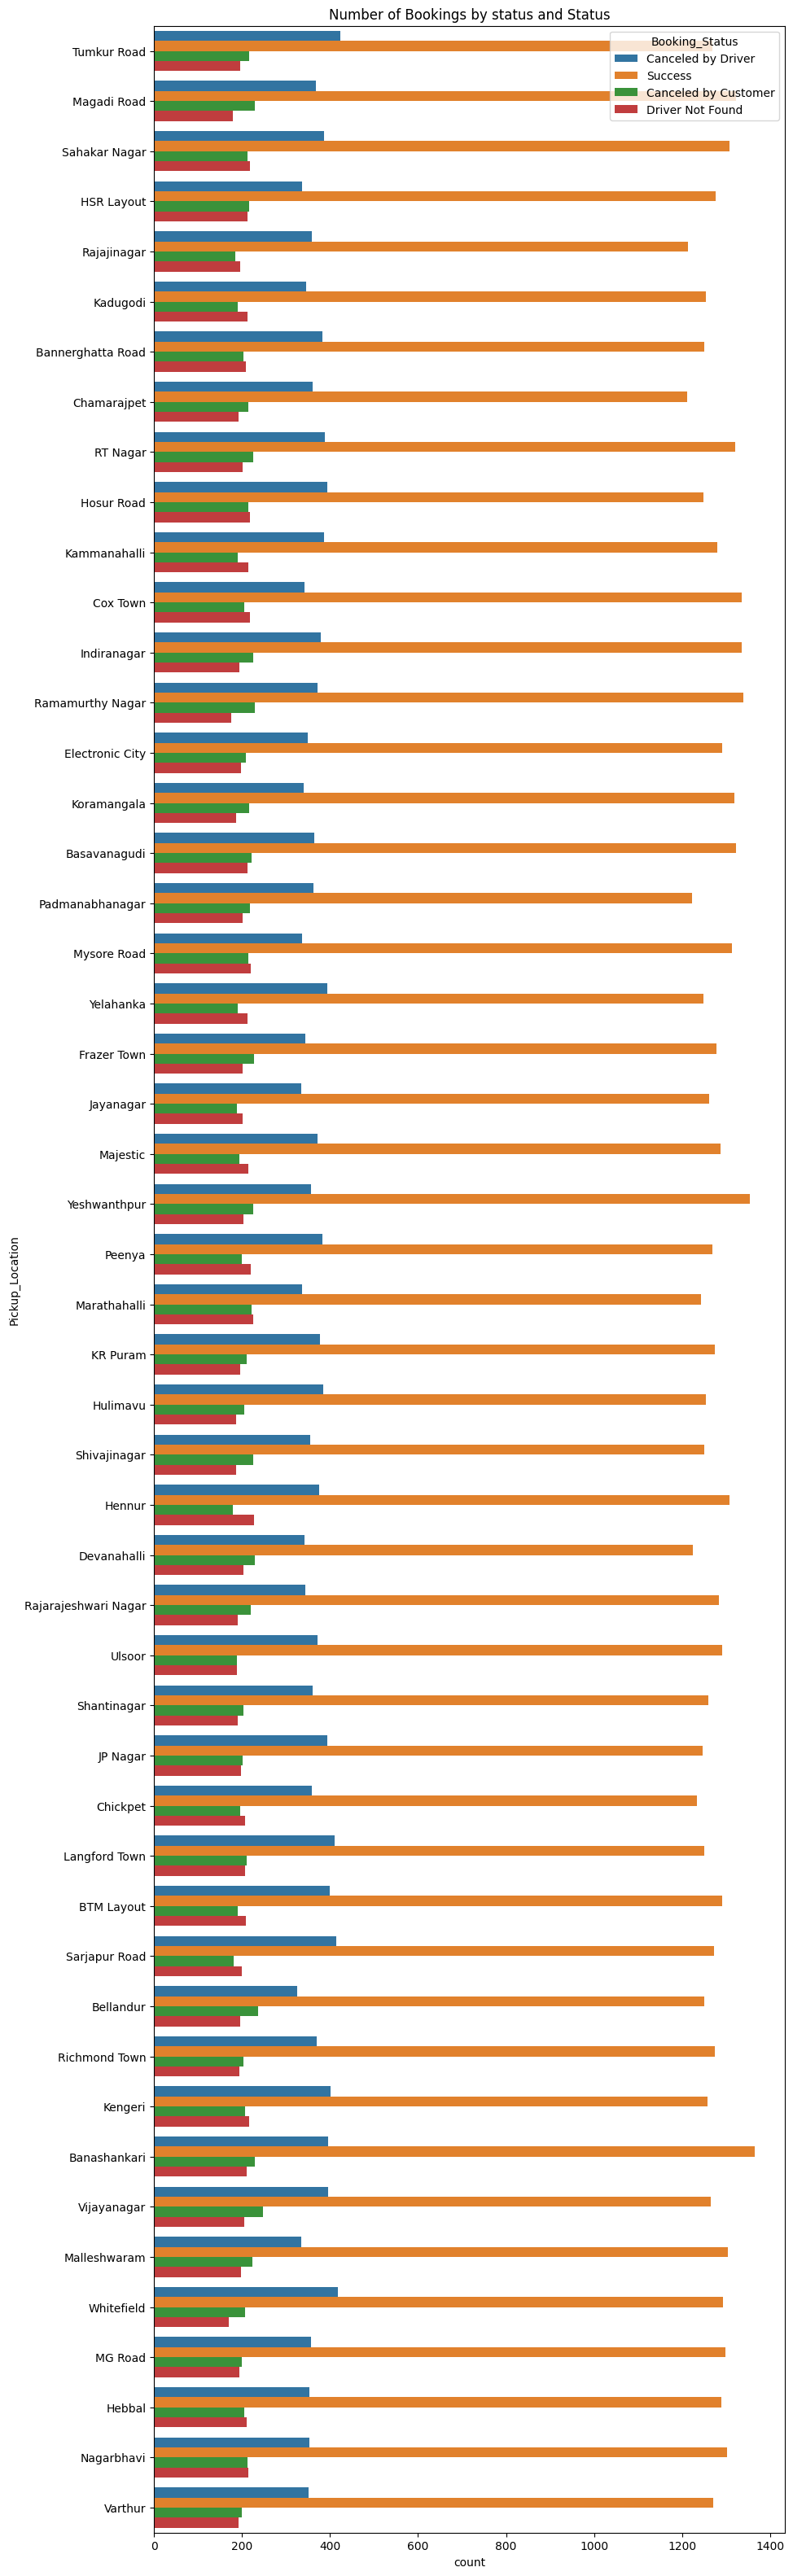

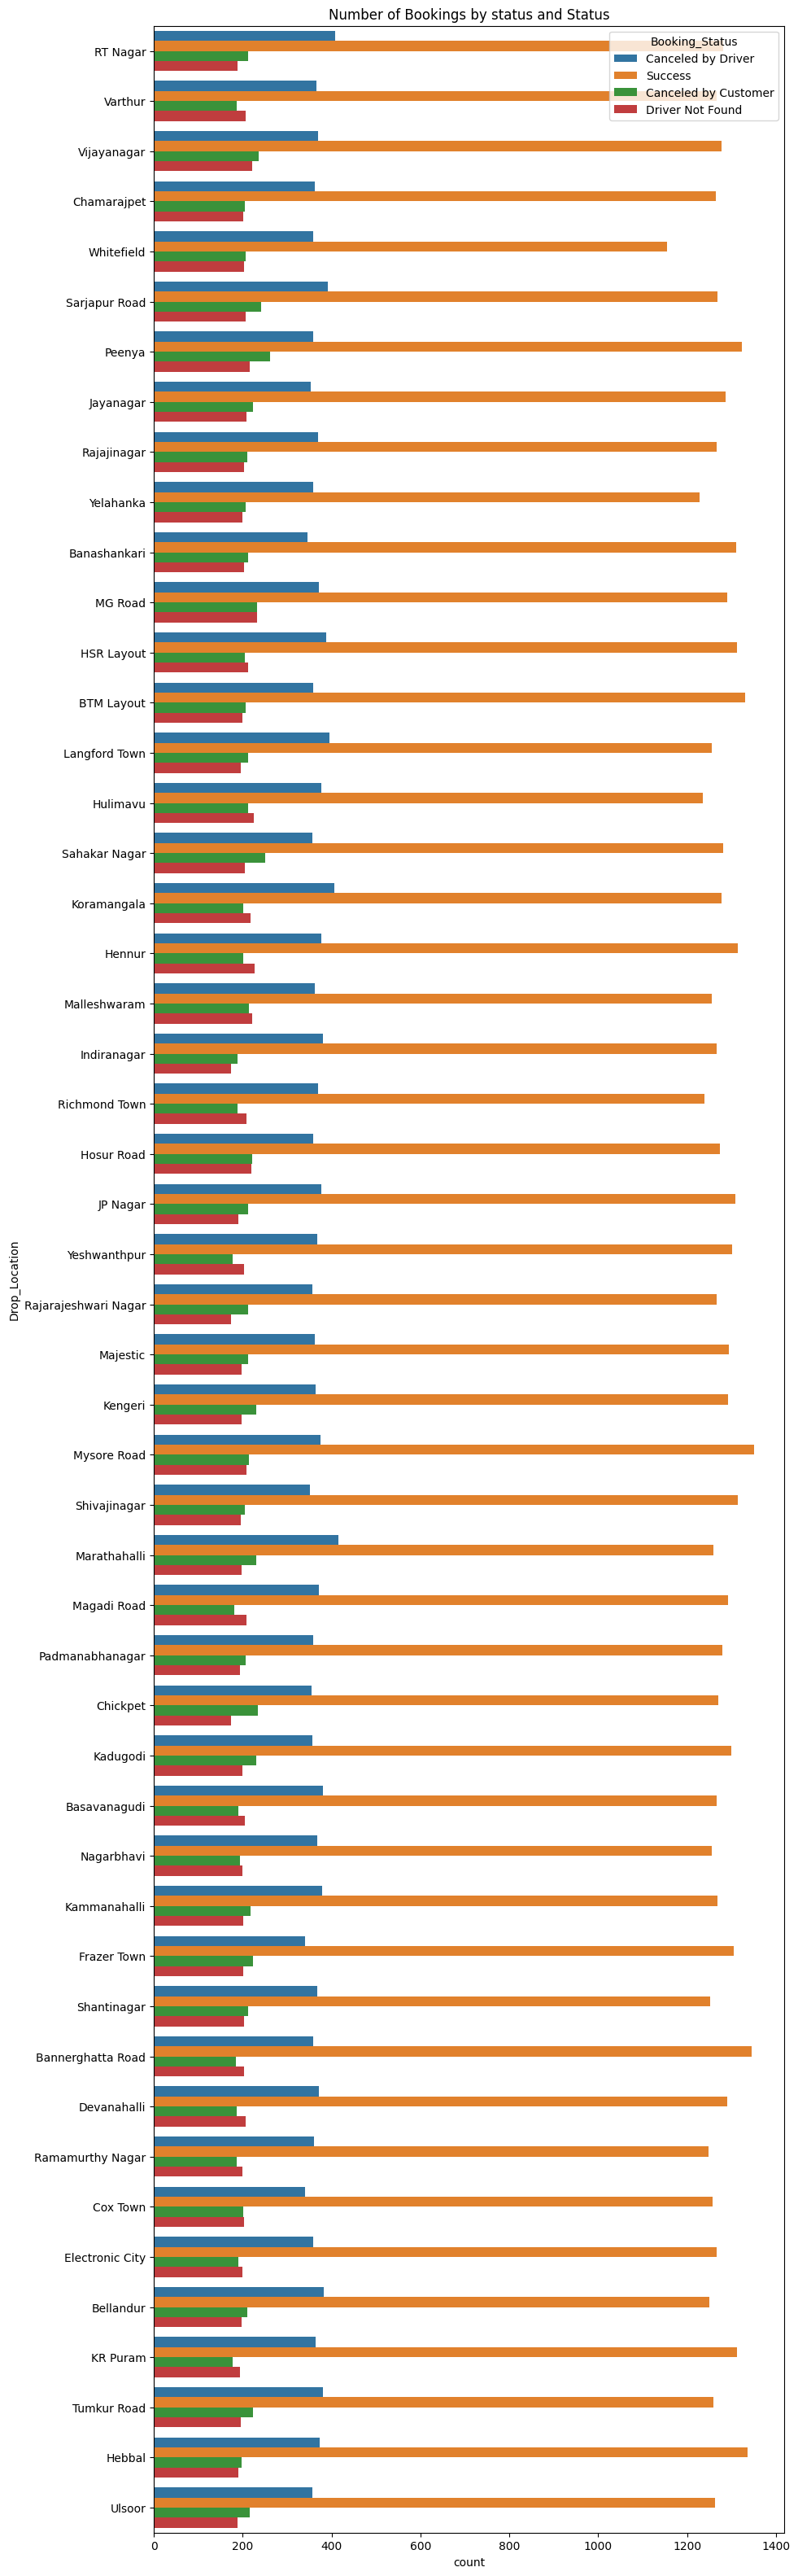

In [42]:
for y in ['Pickup_Location','Drop_Location']:
    plt.figure(figsize= (10,40))
    sns.countplot(data=data, y=y, hue='Booking_Status')
    plt.title(f'Number of Bookings by status and {x}')
    plt.show()

# Main Analysis

---

# Ride Booking Performance Analysis

Approximately **41.72% of bookings failed to reach successful completion**, representing more than **₹23.7 million in unrealised booking value**. This highlights a substantial operatvenue challenge within the ride-booking system.

Overall, only **58.28%** of bookings resulted in a successfully completed ride, while **37.91%** were cancelled and **3.81%** were classified as incomplete rides.

Initial analysis indicates that **driver-related issues** are the primary contributor to unsuccessful bookings. **Driver cancellations** accounted for **17.89%** of all bookings, while **9.83%** resulted in a **Driver Not Found** status.

These findings suggest that **supply-side (driver-side) constraints** are a major contributor to unsuccessful bookings and unrealised booking value.

To better understand the underlying drivers of these failures, we next examine the specific reasons behind **driver-initiated cancellations**, **customer-initiated cancellations**, and **incomplete rides**.
d" status.

In [44]:
print(pd.merge(
    data['Status'].value_counts(normalize=True).mul(100).round(2).reset_index().rename(columns={'proportion':'Percentage'}),
    data['Status'].value_counts().reset_index(name='Total'), 
    on='Status'), "\n")

print(f"Total Canceled Orders: {data['Booking_ID'].nunique() - data[data['Booking_Status']=='Success']['Booking_ID'].nunique()}")
print(f"Total Incomplete Orders: {data[data['Status']== 'Incomplete Ride']['Booking_ID'].nunique()}")

                 Status  Percentage  Total
0               Success       58.28  60041
1    Canceled by Driver       17.89  18434
2  Canceled by Customer       10.19  10499
3      Driver Not Found        9.83  10124
4       Incomplete Ride        3.81   3926 

Total Canceled Orders: 39057
Total Incomplete Orders: 3926


In [45]:
# The cancelled rides account for 23.7 million 
print(data.groupby(['Status'])['Booking_Value'].sum().reset_index())
print(f"Total booking value associated with cancelled and incomplete rides: {data['Booking_Value'].sum() - data[data['Status']=='Success']['Booking_Value'].sum()}")

                 Status  Booking_Value
0  Canceled by Customer        5770901
1    Canceled by Driver       10183427
2      Driver Not Found        5499819
3       Incomplete Ride        2250482
4               Success       32829985
Total booking value associated with cancelled and incomplete rides: 23704629


## Root Cause Analysis of Unsuccessful Bookings
---
### 1. Driver Cancellations: Mostly Triggered by Customer-Related Factors

The largest driver cancellation category was **Personal & Car related issue (35.49%)**. However, when customer-related categories are combined **(Customer related issue, Customer was coughing/sick, and More than permitted people in there)**, they account for 11,892 out of 18,434 driver cancellations **(64.5%)**. This suggests that many driver cancellations are triggered by trip conditions involving passengers rather than purely driver-side operational problems.

In [47]:
# Driver Cancelled, why?
driver_cancel=pd.merge(data['Canceled_Rides_by_Driver'].value_counts().reset_index(),
         data['Canceled_Rides_by_Driver'].value_counts(normalize=True).mul(100).round(2).reset_index(),
         on='Canceled_Rides_by_Driver')
print(pd.merge(driver_cancel, data.groupby(['Canceled_Rides_by_Driver'])['Booking_Value'].sum(), on='Canceled_Rides_by_Driver'))
print(f"Total amount of driver cancelled rides that are due to customer related factors: {data[data['Status']=='Canceled by Driver']['Booking_ID'].nunique() - data[data['Canceled_Rides_by_Driver']=='Personal & Car related issue']['Booking_ID'].nunique()}")
print(f"Total amount of driver cancelled rides: {data[data['Status']=='Canceled by Driver']['Booking_ID'].nunique()}")

# 35.49% drivers canceled rides are due to personal and car related issue.
# Mostly driver canceled the rides due to customers issue, around 11,892 out of 18,434 were canceled
# The majority of driver cancellations appear to be associated with customer-related circumstances, including customer-related issues, health concerns, and situations involving more passengers than permitted.


              Canceled_Rides_by_Driver  count  proportion  Booking_Value
0         Personal & Car related issue   6542       35.49        3667651
1               Customer related issue   5413       29.36        2940828
2           Customer was coughing/sick   3654       19.82        1987669
3  More than permitted people in there   2825       15.32        1587279
Total amount of driver cancelled rides that are due to customer related factors: 11892
Total amount of driver cancelled rides: 18434


### 2. Customer Cancellations: Largely Associated with Driver Behaviour

Customer cancellations were dominated by **Driver is not moving towards pickup location (30.24%)** and **Driver asked to cancel (25.43%)**. When these categories are **combined with AC is Not working**, approximately **70.6%** of **customer cancellations are linked to driver-related** or service-related factors, indicating that operational reliability is a major contributor to customer dissatisfaction.

In [49]:
# Customer Cancelled, why?
# 70.6% of customers canceled rides were due to driver related issue.
cust_cancel=pd.merge(data.groupby(['Canceled_Rides_by_Customer']).size().reset_index(name='Count').sort_values('Count', ascending=False),
         data['Canceled_Rides_by_Customer'].value_counts(normalize=True).mul(100).round(2),
         on='Canceled_Rides_by_Customer')
print(pd.merge(cust_cancel, data.groupby(['Canceled_Rides_by_Customer'])['Booking_Value'].sum(), on='Canceled_Rides_by_Customer'))
print(f'Number of rides canceled by customers due to driver related factors: {data[data['Canceled_Rides_by_Customer'].isin(['Driver is not moving towards pickup location','Driver asked to cancel','AC is Not working'])]['Booking_ID'].nunique()}')
print("Proportion of rides canceled by customers due to driver related factors:",cust_cancel[~cust_cancel['Canceled_Rides_by_Customer'].isin(['Change of plans','Wrong Address'])]['proportion'].sum(),"%")

                     Canceled_Rides_by_Customer  Count  proportion  \
0  Driver is not moving towards pickup location   3175       30.24   
1                        Driver asked to cancel   2670       25.43   
2                               Change of plans   2081       19.82   
3                             AC is Not working   1568       14.93   
4                                 Wrong Address   1005        9.57   

   Booking_Value  
0        1800191  
1        1441602  
2        1136636  
3         849109  
4         543363  
Number of rides canceled by customers due to driver related factors: 7413
Proportion of rides canceled by customers due to driver related factors: 70.6 %


In [50]:
# Additional Observation: AC-Related Service Issues
# Although not the primary reason for customer cancellations, "AC is Not Working" accounted for 14.93% of customer-cancelled rides.
# The issue was relatively distributed across vehicle types, with Prime SUV showing the highest number of AC-related complaints, followed by Bike and eBike.
# No strong temporal pattern was observed across the week, although average counts appeared slightly higher on Monday–Wednesday compared to the rest of the week.
# This suggests that AC-related complaints exist across multiple vehicle categories and may reflect a broader service quality issue rather than a problem isolated to a specific vehicle type.

In [51]:
# AC is Not working, mainly from Prime SUV, Bike, eBike
Ac_issue=data[data['Canceled_Rides_by_Customer']=='AC is Not working'].groupby(['Vehicle_Type']).size().reset_index(name='AC_Issue').sort_values('AC_Issue', ascending=False)
Ac_issue['Total'] = 1568
Ac_issue['%'] = Ac_issue['AC_Issue'] *100/ Ac_issue['Total']
Ac_issue

,Vehicle_Type,AC_Issue,Total,%
4,Prime SUV,252,1568,16.071429
1,Bike,236,1568,15.051020
6,eBike,230,1568,14.668367
2,Mini,228,1568,14.540816
0,Auto,220,1568,14.030612
3,Prime Plus,215,1568,13.711735
5,Prime Sedan,187,1568,11.926020


In [52]:
data[data['Canceled_Rides_by_Customer']=='AC is Not working'].groupby(['Date','DayOfWeek']).size().reset_index(name='Count').groupby(['DayOfWeek'])['Count'].mean()
#.reset_index().sort_values('Booking_ID', ascending=False)

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\3575243550.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data[data['Canceled_Rides_by_Customer']=='AC is Not working'].groupby(['Date','DayOfWeek']).size().reset_index(name='Count').groupby(['DayOfWeek'])['Count'].mean()
C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\3575243550.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data[data['Canceled_Rides_by_Customer']=='AC is Not working'].groupby(['Date','DayOfWeek']).size().reset_index(name='Count').groupby(['DayOfWeek'])['Count'].mean()


DayOfWeek
Mon    8.451613
Tue    8.419355
Wed    8.064516
Thu    5.870968
Fri    6.516129
Sat    6.967742
Sun    6.290323
Name: Count, dtype: float64

### 3. Incomplete Rides: Vehicle Breakdowns and Customer Demand Are a Major Contributor---

A total of **3,926 rides (3.81% of all bookings)** were classified as incomplete rides.

The two dominant causes of incomplete rides were **Customer Demand (40.78%)** and **Vehicle Breakdown (40.52%)**, while **Other Issues** accounted for **18.70%**.

From a revenue perspective, Vehicle Breakdown resulted in approximately **₹919,360** of unrealised booking value, followed closely by Customer Demand at **₹553** 5**.

A notable finding is that Vehicle Breakdown alone accounts for over 40% of all incomplete rides. This reinforces the broader pattern observed throughout the analysis, where operational and supply-side issues play a significant role in unsuccess ouride **
tcomes.

Although vehicle-type and TAT analyses were explored, only minor differences were observed across categories. This suggests that incomplete rides are largely driven by system-wide operational factors rather than being concentrated within specific vehi
	730.846154

In [54]:
print (f"Total number of incomplete rides: {data[data['Incomplete_Rides']=='Yes']['Booking_ID'].nunique()}")

Total number of incomplete rides: 3926


In [55]:
#Incomplete rides
# Incomplete rides happened due to:
# 1. Customer Demand, which causes a loss of potential revenue of around ₹903,535.
# 2. Vehicle Breakdown, which causes a loss of potential revenue of around ₹919,360.
# 3. Other Issue, which causes a loss of potential revenue of around ₹427,587

# We found that although the majority of incomplete rides are due to Customer Demand or Vehicle Breakdown, 
# most of the potential revenue loss is still driven by these two categories. 
# However, the “Other Issue” category shows a slightly higher average booking value compared to the other reasons.

# This suggests that the potential revenue loss per ride is marginally higher for “Other Issue”, 
# although the difference in mean booking value between Vehicle Breakdown and Other Issue is very small (around ₹5).
# It should be noted that Vehicle Breakdown accounts for 40.52% of all incomplete rides, 
# which further highlights the impact of driver and vehicle-related issues on ride completion. 
# This indicates that improving vehicle reliability (e.g., maintenance and condition checks) could help reduce incomplete rides and minimize revenue loss.

Incomplete_rides=data[data['Incomplete_Rides']=='Yes']
Incomplete=pd.merge(Incomplete_rides.groupby('Incomplete_Rides_Reason').size().reset_index(name='Count'), Incomplete_rides['Incomplete_Rides_Reason'].value_counts(normalize=True).mul(100).round(2).reset_index().rename(columns={'proportion':'Percentage'}),
         on='Incomplete_Rides_Reason')
pd.merge(data.groupby(['Incomplete_Rides_Reason'])['Booking_Value'].aggregate(['sum','mean']).reset_index(), Incomplete)

,Incomplete_Rides_Reason,sum,mean,Count,Percentage
0,Customer Demand,903535,564.356652,1601,40.78
1,Other Issue,427587,582.543597,734,18.70
2,Vehicle Breakdown,919360,577.850409,1591,40.52


<Axes: xlabel='Incomplete_Rides_Reason', ylabel='Incomplete_Rate'>

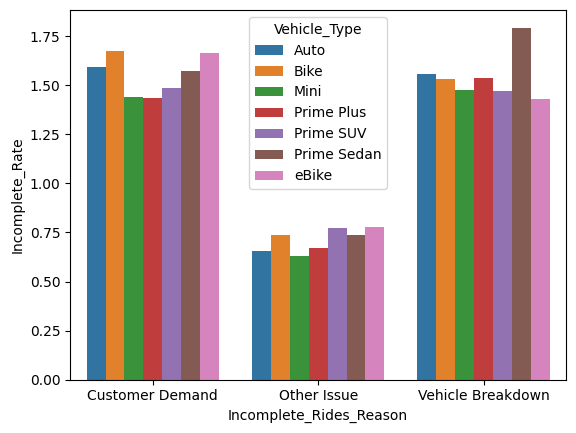

In [56]:
# It appears that incomplete rides are not strongly driven by vehicle type, as the proportions across different categories are relatively similar with only minor differences.
# Customer Demand: eBike, Bike, and Auto show slightly higher proportions of incomplete rides due to customer demand.
# Other Issue: Prime SUV and eBike have a slightly higher share of incomplete rides under “Other Issue”.
# Vehicle Breakdown: Prime Sedan, Prime Plus, and Mini show slightly higher proportions of incomplete rides due to vehicle breakdown.
# Overall, the differences across vehicle types are small, suggesting that incomplete rides are largely driven by system-wide factors rather than strongly vehicle-specific behavior.

Incomplete_vehicle=Incomplete_rides.groupby(['Incomplete_Rides_Reason','Vehicle_Type'])['Booking_ID'].count().reset_index()
total_vehicle= data.groupby(['Vehicle_Type'])['Booking_ID'].count().reset_index(name='Total')
merge_vehicle=Incomplete_vehicle.merge(total_vehicle, on='Vehicle_Type')
merge_vehicle['Incomplete_Rate']= merge_vehicle['Booking_ID']*100/merge_vehicle['Total']
sns.barplot(merge_vehicle, x='Incomplete_Rides_Reason',y='Incomplete_Rate',hue='Vehicle_Type')

In [57]:
pd.crosstab(Incomplete_rides['Vehicle_Type'], Incomplete_rides['Incomplete_Rides_Reason'], normalize='index')

Incomplete_Rides_Reason,Customer Demand,Other Issue,Vehicle Breakdown
Vehicle_Type,,,
Auto,0.418149,0.172598,0.409253
Bike,0.424870,0.186528,0.388601
Mini,0.406190,0.177950,0.415861
Prime Plus,0.393657,0.184701,0.421642
Prime SUV,0.398537,0.206581,0.394881
Prime Sedan,0.382979,0.180033,0.436989
eBike,0.430314,0.200348,0.369338


In [58]:
# pd.pivot_table(data=Incomplete_rides,columns='Incomplete_Rides_Reason', index='Vehicle_Type', values='Booking_Value', aggfunc='mean')

In [59]:
# The highest booking value on average is actually accepted by drivers only after 5 minutes.
# >5 minutes	605.773148
# This might be slighly out of logic due to higher booking value, drivers tend to quickly accepts because they will get higher revenue (hypothesis). However, the data doesn't say so, and this could be explained e.g. due to outskirts area, no one want to take the orders, even if higher value offered, drivers might feel not worth it.
# Customers tend to onboard to vehicle with less than 3 minutes. 



# # left exclusive, right inclusive. e.g. 0 is not included, but 60 is included, so it's 0<x<= 60

# Incomplete_rides['V_TAT_Groups']= pd.cut(data['V_TAT'], bins=[0,60,120,180,240,300,360], labels=['0-1 minutes','1-2 minutes','2-3 minutes','3-4 minutes','4-5 minutes','>5 minutes'])
# Incomplete_rides['C_TAT_Groups']= pd.cut(data['C_TAT'], bins=[0,60,120,180], labels=['0-1 minutes','1-2 minutes','2-3 minutes'])
# print(Incomplete_rides.groupby(['V_TAT_Groups'])['Booking_Value'].mean().reset_index())
# print(Incomplete_rides.groupby(['C_TAT_Groups'])['Booking_Value'].mean().reset_index())



In [60]:
# Incomplete_rides.groupby(['V_TAT_Groups','C_TAT_Groups'])['Booking_Value'].mean().reset_index()


In [61]:
# pd.pivot_table(data=Incomplete_rides, index='Driver_Ratings', columns='Customer_Rating', values= 'Booking_ID', aggfunc='count')

## Key Finding: Supply-Side Constraints Consistently Appear Across Failure Types

Across multiple analyses, operational and **supply-side factors** consistently emerge as a major contributor to unsuccessful booking outcomes.

* **Driver cancellations (17.89%)**
* **Driver Not Found cases (9.83%)**
* **70.6% of customer cancellations linked to driver/service-related factors**
* **Vehicle Breakdown accounting for 40.52% of incomplete rides**

Taken together, these findings suggest that operational reliability and supply-side constraints play a significant role in reducing ride completion rates and contributing to unrealised booking value.




                                                                                                                      

### **Revenue Impact and Recovery Potential**
---

The operational and supply-side issues identified above are not only affecting ride completion rates but are also resulting in a substantial **business and revenue impact**.

Unsuccessful bookings account for more than **₹23.7 million in unrealised booking value**, representing a significant volume of demand that was **not converted into completed rides**.

However, the true business impact depends on whether these failed bookings are eventually recovered. If customers **rebook quickly and complete a ride**, part of this lost value may sti**ll be rec**overed. If not, these failures represent **permanent revenue leakage and lost ride opportunities**.

To evaluate this, we next examine **customer rebooking behaviour following unsuccessful bo .



---
Do note : 
The analysis estimates approximately ₹23.7 million in unrealised booking value from unsuccessful bookings. However, this should not be interpreted as direct revenue loss to the platform.

The dataset does not contain information on commission rates, driver payouts, incentives, taxes, or profitability. As a result, the actual financial impact on the platform cannot be directly quantified.

Therefore, the ₹23.7 million figure should be interpreted as the value of customer demand that was not converted into completed rides rather than realised revenue loss..
d loss.


### **Key Behavioural Insight: Low Same-Day Recovery**

The analysis shows that customers **almost never rebook within the same day after a cancellation or failed ride**, regardless of whether the failure originated from the driver side or customer side.

This pattern is consistent across all cancellation reasons, indicating that unsuccessful bookings are **not typically recovered through immediate retry behaviour**.

### **Implication: Revenue Loss is Largely Irreversible in the Short Term**

This means that most failed bookings do not convert into later successful rides within the same day. As a result, unsuccessful bookings often translate directly into **immediate and effectively irreversible revenue loss**, rather than temporary delays in fulfilment.
uptions.

In [72]:
# After a cancellation with reason X, did the customer make another booking later on the same day?
def cancellation_reorder(data,column,reason):
    df= data.sort_values(['Customer_ID','Date','Time']).copy()
    cancelled= df[df[column]== reason].copy()
    rebooked=[]
    for _, row in cancelled.iterrows():
        customer_id =row['Customer_ID']
        date= row['Date']
        time= row['Time']
        later= df[(df['Customer_ID']== customer_id) & (df['Date']==date) & (df['Time']>time)]
        rebooked.append(len(later)>0)

    cancelled['Rebooked'] = rebooked
    print("Rebook Rate:", round(cancelled['Rebooked'].mean() *100,2),"%")
    print(cancelled['Rebooked'].value_counts())
    return cancelled[cancelled['Rebooked']==True]
        

In [73]:
reasons= data['Canceled_Rides_by_Customer'].dropna().unique()

for x in reasons:
    print('Reasons:', x)
    print(cancellation_reorder(
        data, 'Canceled_Rides_by_Customer',x))

Reasons: Driver is not moving towards pickup location
Rebook Rate: 0.35 %
Rebooked
False    3164
True       11
Name: count, dtype: int64
             Date      Time     Booking_ID        Booking_Status Customer_ID  \
30756  2024-07-04  01:49:00  CNR1626542960  Canceled by Customer   CID167427   
20455  2024-07-02  07:25:00  CNR4526638969  Canceled by Customer   CID186580   
34111  2024-07-20  10:06:00  CNR6116181526  Canceled by Customer   CID441587   
51318  2024-07-16  20:40:00  CNR8699065459  Canceled by Customer   CID475244   
45733  2024-07-10  09:56:00  CNR6587548846  Canceled by Customer   CID533295   
34287  2024-07-24  15:26:00  CNR4915588914  Canceled by Customer   CID558349   
82649  2024-07-08  13:07:00  CNR9033980467  Canceled by Customer   CID686501   
91777  2024-07-22  20:26:00  CNR3141821553  Canceled by Customer   CID693149   
68295  2024-07-12  05:31:00  CNR9773038146  Canceled by Customer   CID760850   
31734  2024-07-10  02:41:00  CNR1214321761  Canceled by Custome

In [74]:
reasons_driver= data['Canceled_Rides_by_Driver'].dropna().unique()

for x in reasons_driver:
    print('Reasons:', x)
    print(cancellation_reorder(
        data, 'Canceled_Rides_by_Driver',x))

Reasons: Personal & Car related issue
Rebook Rate: 0.21 %
Rebooked
False    6528
True       14
Name: count, dtype: int64
              Date      Time     Booking_ID      Booking_Status Customer_ID  \
7157    2024-07-12  18:22:00  CNR8690153876  Canceled by Driver   CID171890   
31300   2024-07-02  23:15:00  CNR1864609923  Canceled by Driver   CID448973   
90593   2024-07-05  01:06:00  CNR6644651006  Canceled by Driver   CID519691   
101782  2024-07-31  03:21:00  CNR8007988073  Canceled by Driver   CID543568   
11265   2024-07-04  21:09:00  CNR6818451449  Canceled by Driver   CID568737   
97572   2024-07-15  01:10:00  CNR5161238428  Canceled by Driver   CID572920   
56673   2024-07-24  00:03:00  CNR6547201937  Canceled by Driver   CID586645   
88409   2024-07-30  15:11:00  CNR5333068930  Canceled by Driver   CID597579   
60686   2024-07-25  08:58:00  CNR4055771046  Canceled by Driver   CID666039   
14315   2024-07-02  10:29:00  CNR2612296880  Canceled by Driver   CID691300   
39326   20

In [75]:
print(cancellation_reorder(data, 'Booking_Status','Driver Not Found'))

Rebook Rate: 0.12 %
Rebooked
False    10112
True        12
Name: count, dtype: int64
              Date      Time     Booking_ID    Booking_Status Customer_ID  \
39136   2024-07-06  17:23:00  CNR6325744760  Driver Not Found   CID116471   
26314   2024-07-17  03:34:00  CNR8162000198  Driver Not Found   CID253884   
101181  2024-07-31  12:54:00  CNR5269605228  Driver Not Found   CID263459   
66654   2024-07-19  14:43:00  CNR1689710271  Driver Not Found   CID268026   
102506  2024-07-31  00:05:00  CNR3038383019  Driver Not Found   CID465260   
94425   2024-07-06  01:44:00  CNR4399448123  Driver Not Found   CID566302   
47392   2024-07-15  04:49:00  CNR1153061288  Driver Not Found   CID576624   
32863   2024-07-14  01:54:00  CNR6151338861  Driver Not Found   CID633873   
43876   2024-07-24  06:32:00  CNR2454913166  Driver Not Found   CID672623   
39591   2024-07-26  07:59:00  CNR1209560790  Driver Not Found   CID927444   
88622   2024-07-12  12:33:00  CNR1657609364  Driver Not Found   CID9

### **From Immediate Recovery to Repeat Booking Behaviour**

The previous analysis shows that unsuccessful bookings are rarely recovered within the same day, indicating that failed rides typically result in immediate loss of the booking opportunity.

However, a key question remains:
**Do customers continue using the platform after experiencing unsuccessful bookings within the observation period?**

To understand this, we extend the analysis to **repeat customer behaviour across the entire dataset**.


### **Repeat Customer Analysis**


Out of **94,544 total customers**, only **7,954 (≈8.4%)** made more than one booking during the observation period, indicating that repeat usage of the platform is relatively limited.

Among these repeat customers:

* **3,653 customers** had only successful bookings
* **1,725 customers** had only unsuccessful bookings, indicating repeated exposure to **service failures**
* **2,576 customers** experienced mixed outcomes (both success and failure)

This distribution shows that while repeat usage exists, customer experience is highly uneven across users.

A particularly important segment is the **1,725 customers who experienced only unsuccessful bookings across alobserved bookingsns**. Unlike one-off failures, this group reflects **repeated exposure to service failure despite continued attempts to use the platform**, making it a key indicator of persistent unmet demand rather than isolated incident
?**


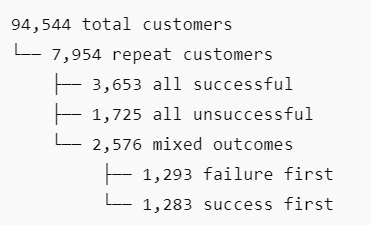

In [91]:
#How many repeat customers do the company have?
repeat_book=data.groupby(['Customer_ID']).aggregate({'Booking_ID':'count'}).reset_index()
repeat_book= repeat_book[repeat_book['Booking_ID']>1]
repeat_book['Customer_ID'].nunique()
#around 7954 customers are repeat bookings [order at least 2 times]

7954

In [92]:
repeated_data=data[data['Customer_ID'].isin(repeat_book['Customer_ID'])]

#Out of 7954 customers who repeated their orders or bookings, 
#how many customers did that due to loyal and satisfied and then reorder 
#or due to cancelled rides and need to reorder?


#Number of customers who repeated their orders, not due to cancelled bookings and reorder
#it's not related to cancelled rides

# From the 7954 repeat bookings, we will check the order status for each customer
book_stat=repeated_data.groupby(['Customer_ID','cancelled']).size().reset_index(name='count')
book_stat=book_stat.groupby('Customer_ID')['cancelled'].count().reset_index()
# we get repeat bookings customers who have only 1 order status
book_stat_1= book_stat.copy()
book_stat_1= book_stat_1[book_stat_1['cancelled']==1] 
#So either here all rides successful or all rides cancelled.
print("Number of customers who repeat bookings and only have 1 order status",book_stat_1['Customer_ID'].nunique())
success_repeat_order= data[data['Customer_ID'].isin(book_stat_1['Customer_ID'])]#get the data of customers who has only 1 order status
success_repeat_order=success_repeat_order[success_repeat_order['cancelled']==0]
print("Number of customers who repeat bookings and all success orders",success_repeat_order['Customer_ID'].nunique())
print(f"This means, number of customers who repeat bookings and still unsuccessful is {5378-3653}")

#Those repeat orders and successful are not an issue (3653). 
#This means 3653 customers repeatedly used the platform despite never experiencing a cancellation. or at least willing to use our service again 
#While there's around 1725 customers who experienced only unsuccessful bookings.

Number of customers who repeat bookings and only have 1 order status 5378
Number of customers who repeat bookings and all success orders 3653
This means, number of customers who repeat bookings and still unsuccessful is 1725


To better understand the behaviour of the **1,725 customers who consistently experienced unsuccessful bookings**, we investigate whether repeated failures occur within a short time window or are distributed across separate booking sessions.

Specifically, we examine two possible behavioural patterns:

1. **Immediate retry behaviour**, where customers attempt multiple bookings shortly after a failed ride due to urgency or unmet demand
2. **Independent booking behaviour**, where multiple failed bookings occur across different days, reflecting recurring travel needs rather than immediate retry attempts

Understanding this distinction helps determine whether repeated failures represent **continuous retry loops or separate instances of unmet demand over time**.


In [94]:
#We have the unsuccessful repeat orders by customers
unsuccessful_orders=book_stat_1[~book_stat_1['Customer_ID'].isin(success_repeat_order['Customer_ID'])]
print(unsuccessful_orders['Customer_ID'].nunique())

#customer data who face all failure orders
unsuccessful_data=data[data['Customer_ID'].isin(unsuccessful_orders['Customer_ID'])]


1725


Only **19 customer-day combinations** show multiple failed bookings on the same day, and in every case, customers made exactly **two attempts**.

This indicates that **same-day retry behaviour is extremely rare** among customers who experience repeated booking failure This further supporting the earlier finding that unsuccessful bookings are rarely recovered within the same day.s.

Instead, most customers in the **1,725 consistently unsuccessful repeat customer group** do not attempt immediate retries. Rather, they return on **different days and continue to experience unsuccessful bookings**, suggesting that failures are distributed across separate booking sessions rather than concentrated retry loops.

Additionally, **1,071 customers repeatedly placed bookings at the sam and locatione time across different days despite prior failures**, indicating recurring travel patterns such as commuting schedules rather than reactive retry behaviour.


In [98]:
#Number of bookings per customer per day
#For customers who face multiple failure orders
same_day_attempts=unsuccessful_data.groupby(['Customer_ID','Date']).size().reset_index(name='Attempts')
keep_retry=same_day_attempts[same_day_attempts['Attempts']>1]
keep_retry.describe()

#Among customers who repeatedly experienced unsuccessful bookings, those who retried on the same day made 2 booking attempts

,Attempts
count,19.0
mean,2.0
std,0.0
min,2.0
25%,2.0
50%,2.0
75%,2.0
max,2.0


In [100]:
#For the other customers who had all unsuccessful rides, do they repeatedly book at the exact same time across multiple dates?
same_time=unsuccessful_data.groupby(['Customer_ID','Time','Pickup_Location','Drop_Location']).aggregate({'Date':'nunique',
                                                             'Booking_ID' :'count'}).reset_index()
same_time=same_time[same_time['Date']>1]
print(f'Among the 1725 all failure repeat customers, {same_time['Customer_ID'].nunique()} repeatedly booked at the same booking time across multiple dates (same exact time, drop up and pick up location)')

Among the 1725 all failure repeat customers, 1071 repeatedly booked at the same booking time across multiple dates (same exact time, drop up and pick up location)


However, when interpreting the **1,071 customers who repeatedly booked at the same time and route across different days**, an important caveat must be considered.

The observed pattern may reflect **genuine recurring travel demand**, such as regular commuting schedules (e.g. work start/end times or routine trips). For example, customers such as **CID100616** show repeated bookings at identical times across different days (e.g. 13:53 on multiple dates), which is consistent with structured daily travel behaviour.

At the same time, the consistency in **exact time, route, and vehicle type across multiple customers and days** raises the possibility that part of this pattern may also reflect **systematic or data-level regularity**, rather than purely behavioural variation.

Therefore, while these patterns are consistent with real-world commuting behaviour, they should be interpreted as **potential recurring demand signals rather than definitive behavioural proof**, and further validation would be required to distinguish between true demand patterns and dataset artefacts.
acts.


In [96]:
unsuccessful_data.sort_values(['Customer_ID','Date','Time']).head(10)

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,DayOfWeek,Week,Hour,cancelled,Status
99289,2024-07-29,13:53:00,CNR4924142018,Driver Not Found,CID100616,Bike,Frazer Town,Kengeri,NaN,NaN,NaN,NaN,NaN,NaN,692,NaN,0,NaN,NaN,Mon,2024-07-29/2024-08-04,13,1,Driver Not Found
102051,2024-07-31,13:53:00,CNR4920184924,Driver Not Found,CID100616,Bike,Frazer Town,Kengeri,NaN,NaN,NaN,NaN,NaN,NaN,692,NaN,0,NaN,NaN,Wed,2024-07-29/2024-08-04,13,1,Driver Not Found
561,2024-07-03,17:37:00,CNR8745813955,Canceled by Driver,CID101380,Prime SUV,Vijayanagar,Padmanabhanagar,NaN,NaN,NaN,Customer was coughing/sick,NaN,NaN,849,NaN,0,NaN,NaN,Wed,2024-07-01/2024-07-07,17,1,Canceled by Driver
100517,2024-07-31,17:37:00,CNR8739558745,Canceled by Driver,CID101380,Prime SUV,Vijayanagar,Padmanabhanagar,NaN,NaN,NaN,Customer was coughing/sick,NaN,NaN,849,NaN,0,NaN,NaN,Wed,2024-07-29/2024-08-04,17,1,Canceled by Driver
99600,2024-07-19,10:17:00,CNR8095819450,Canceled by Driver,CID103712,Mini,KR Puram,Sarjapur Road,NaN,NaN,NaN,Customer related issue,NaN,NaN,304,NaN,0,NaN,NaN,Fri,2024-07-15/2024-07-21,10,1,Canceled by Driver
102362,2024-07-31,10:17:00,CNR8094508095,Canceled by Driver,CID103712,Mini,KR Puram,Sarjapur Road,NaN,NaN,NaN,Customer related issue,NaN,NaN,304,NaN,0,NaN,NaN,Wed,2024-07-29/2024-08-04,10,1,Canceled by Driver
51126,2024-07-02,09:42:00,CNR5944528696,Canceled by Customer,CID103818,Prime SUV,Banashankari,Shantinagar,NaN,NaN,Change of plans,NaN,NaN,NaN,932,NaN,0,NaN,NaN,Tue,2024-07-01/2024-07-07,9,1,Canceled by Customer
42446,2024-07-26,03:41:00,CNR7789387085,Driver Not Found,CID103818,Auto,Bannerghatta Road,Whitefield,NaN,NaN,NaN,NaN,NaN,NaN,1818,NaN,0,NaN,NaN,Fri,2024-07-22/2024-07-28,3,1,Driver Not Found
22,2024-07-16,10:17:00,CNR4306636052,Canceled by Driver,CID103842,Prime SUV,Mysore Road,Vijayanagar,NaN,NaN,NaN,Customer was coughing/sick,NaN,NaN,909,NaN,0,NaN,NaN,Tue,2024-07-15/2024-07-21,10,1,Canceled by Driver
99978,2024-07-31,10:17:00,CNR4360524306,Canceled by Driver,CID103842,Prime SUV,Mysore Road,Vijayanagar,NaN,NaN,NaN,Customer was coughing/sick,NaN,NaN,909,NaN,0,NaN,NaN,Wed,2024-07-29/2024-08-04,10,1,Canceled by Driver


Among repeat customers, **2,576 customers experienced mixed outcomes (both successful and unsuccessful bookings)**.

This group is particularly important because it introduces a **directionality question** that is not captured by simple outcome counts: whether customers first experienced a failure followed by recovery, or a success followed by later service degradation.

Understanding this sequence is critical, as it distinguishes between **service recovery behaviour (failure → success)** and **deterioration in experience (success → failure)**, which have very different implications for customer perception and platform reliability.

To investigate this, we further analyse the order sequence of bookings within this mixed-outcome group.


In [102]:
diff_order_status = data[~data['Customer_ID'].isin(book_stat_1['Customer_ID']) & data['Customer_ID'].isin(repeated_data['Customer_ID'])]

In [103]:
#The rest of 2576 customers are experiencing at least one time success and one time cancelled
diff_order_status['Customer_ID'].nunique()

2576

Among the **2,576 mixed-outcome customers**, the sequence of experiences is almost evenly split:

* **1,293 customers** experienced a failure first, followed by a successful booking later
* **1,283 customers** experienced a successful booking first, followed by a later failure
ed.
ions.
ts.




In [235]:
# 1. For mixed customers, what was their FIRST booking outcome?
first_book_status=diff_order_status.sort_values(['Customer_ID','Date','Time']).groupby(['Customer_ID'])['cancelled'].first().reset_index()
first_book_status['cancelled'].value_counts()
#Around 1293 customers start with failure orders,
#1283 customers start with getting a success orders

cancelled
1    1293
0    1283
Name: count, dtype: int64

The near-equal split between **failure-to-success transitions (1,293)** and **success-to-failure transitions (1,283)** indicates that future booking outcomes are not strongly determined by prior customer experience.

Instead, ride outcomes appear to fluctuate depending on booking conditions, suggesting that service reliability is **not determined by customer history, but by real-time operational factors such as driver availability and supply-demand balance**.


This implies that customer experience is shaped more by **situational supply–demand dynamics at the time and location of booking**, rather than cumulative user-level effects.


This is further supported by observed variation in cancellation rates across pickup–drop routes, where failure rates differ significantly across locations, indicating that operational conditions are not uniform across the network.

### Location Dynamics

In [83]:
#We unable to find insights with drop location alone. We can see how the cancellation rate are vary from 35 to 40%, like very low deviation
data.groupby(['Drop_Location']).aggregate({'cancelled':'mean','Booking_ID':'count'}).describe()

,cancelled,Booking_ID
count,50.000000,50.000000
mean,0.379088,2060.480000
std,0.010723,44.040445
min,0.356767,1923.000000
25%,0.371189,2034.500000
50%,0.378617,2059.500000
75%,0.386779,2090.500000
max,0.401141,2159.000000


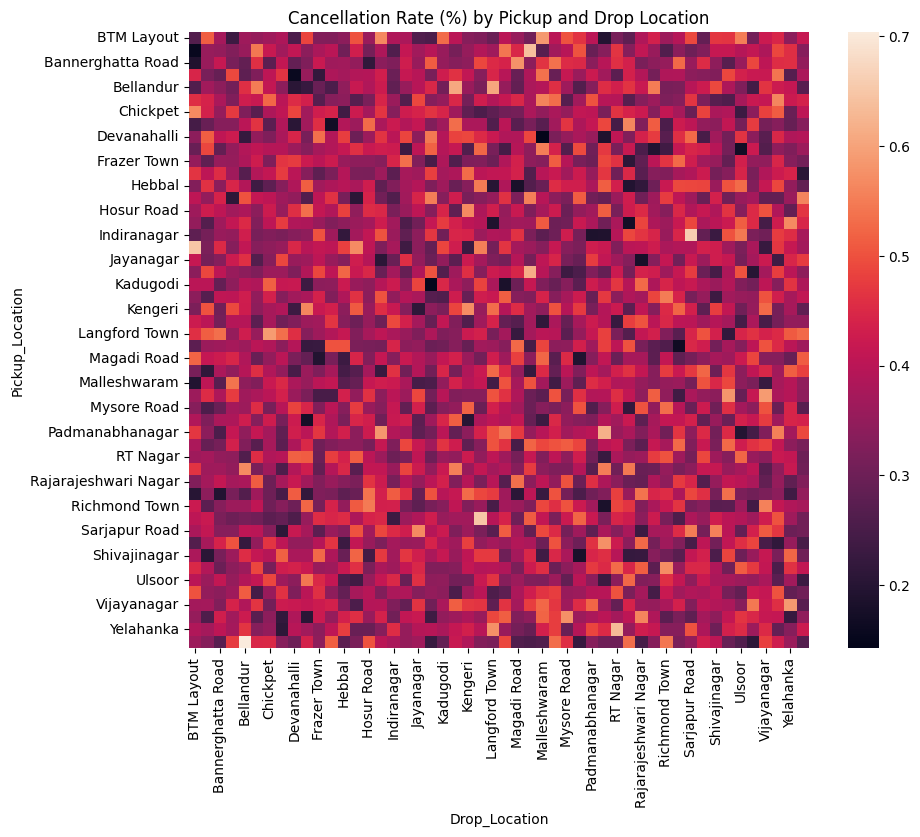

In [277]:
#Check whether drop and pick up location affect cancellation rate
plt.figure(figsize= (10,8))
sns.heatmap(pd.crosstab(index=data['Pickup_Location'], columns=data['Drop_Location'], values= data['cancelled'], aggfunc='mean'))
plt.title('Cancellation Rate (%) by Pickup and Drop Location')
plt.show()

In [85]:
#From heatmap above, we see a huge variation of cancellation rate from around  14% to 70%
#we also need to becareful since high proportion might simply due to lower amount of bookings for that rouete, hence the cancelled orders seems high proportion
#Therefore we checked how much orders per route, shown below
route_pickup_drop=data.groupby(['Pickup_Location','Drop_Location']).aggregate({'cancelled':'mean', 'Booking_ID':'count'}).reset_index()
route_pickup_drop.describe()

,cancelled,Booking_ID
count,2500.000000,2500.000000
mean,0.379101,41.209600
std,0.079597,6.506136
min,0.142857,24.000000
25%,0.325000,37.000000
50%,0.375000,41.000000
75%,0.428571,45.000000
max,0.703704,67.000000


In [86]:
print('High cancelled route', route_pickup_drop.sort_values('cancelled', ascending=False).head(10),'\n')

print('Low cancelled route', route_pickup_drop.sort_values('cancelled', ascending=True).head(10))

#There is interaction between pick up and drop location 

High cancelled route       Pickup_Location  Drop_Location  cancelled  Booking_ID
2454     Yeshwanthpur      Bellandur   0.703704          27
840       Indiranagar  Sarjapur Road   0.659091          44
850          JP Nagar     BTM Layout   0.648649          37
1973    Sahakar Nagar    Koramangala   0.648649          37
77       Banashankari       Majestic   0.640000          50
2434        Yelahanka       RT Nagar   0.631579          38
1633  Padmanabhanagar         Peenya   0.617647          34
977          KR Puram       Majestic   0.615385          26
221         Bellandur   Kammanahalli   0.605263          38
224         Bellandur  Langford Town   0.604651          43 

Low cancelled route       Pickup_Location         Drop_Location  cancelled  Booking_ID
428       Devanahalli          Malleshwaram   0.142857          28
1019         Kadugodi              KR Puram   0.150000          40
50       Banashankari            BTM Layout   0.153846          39
158      Basavanagudi        

# Conclusion

This analysis found that unsuccessful bookings represent a significant operational challenge within the ride-booking platform. Approximately **41.72% of bookings did not result in a completed ride**, corresponding to more than **₹23.7 million in unrealised booking value**.

Root cause analysis revealed that operational and supply-side factors consistently appear across multiple failure types. Driver cancellations, Driver Not Found outcomes, driver-related customer cancellations, and vehicle breakdowns collectively account for a substantial proportion of unsuccessful bookings, suggesting that ride completion is strongly influenced by service availability and operational reliability.

Further analysis of customer behaviour showed that unsuccessful bookings are rarely recovered through immediate retry behaviour. Same-day rebooking following a failed booking was extremely uncommon, indicating that unsuccessful bookings often translate into lost booking opportunities within the observed period.

Among repeat customers, a notable segment continued to experience repeated unsuccessful outcomes across multiple booking attempts. However, these failures were generally distributed across separate booking sessions rather than repeated same-day retry loops, suggesting persistent unmet demand rather than short-term recovery behaviour.

Analysis of mixed-outcome customers further showed that successful and unsuccessful experiences occur in nearly equal sequence patterns. This suggests that booking outcomes are not strongly determined by prior customer experience, but instead fluctuate according to real-time operational conditions.

This interpretation is further supported by substantial variation in cancellation rates across pickup–drop routes, indicating that ride success is influenced by the specific time and location of booking rather than customer history alone.

Overall, the findings suggest that improving operational reliability, driver availability, and route-level service coverage may offer the greatest opportunity to reduce unsuccessful bookings and convert a larger proportion of customer demand into completed rides.


---

# Analysis Limitations

## Observation Period

The dataset covers approximately one month of booking activity. As a result, customer-level findings should be interpreted as repeat booking behaviour observed during the study period rather than evidence of long-term retention, loyalty, or churn.

## Unrealised Booking Value vs Revenue

The analysis estimates approximately **₹23.7 million in unrealised booking value**. However, this should not be interpreted as direct revenue loss to the platform.

The dataset does not contain information on commission rates, driver payouts, incentives, taxes, or profitability. Therefore, the actual financial impact on the platform cannot be directly quantified.

## Customer Identification

The dataset identifies users using `Customer_ID`. However, it is not possible to verify whether each `Customer_ID` corresponds to a unique real-world customer.

As a result, customer-level metrics such as repeat customer counts and booking behaviour should be interpreted with caution, as they are based on `Customer_ID` rather than verified individual customers.

## Behavioural Interpretation

A number of customers repeatedly placed bookings at identical times and routes across multiple dates. These patterns may reflect genuine recurring travel demand, such as commuting behaviour, but could also be influenced by characteristics of the dataset.

Therefore, these patterns should be interpreted as potential demand signals rather than definitive behavioural proof.

## Causality

The analysis identifies relationships between booking outcomes and operational factors. However, the available data does not allow causal conclusions to be established regarding why individual booking failures occurred.


# Future Analysis Opportunities

### 1. Long-Term Customer Retention and Churn

The current dataset covers a relatively short observation period and does not allow long-term customer behaviour to be evaluated. Future analysis using longer customer histories could investigate whether repeated unsuccessful bookings increase the likelihood of customer churn and quantify the associated customer lifetime value impact.

### 2. Driver Supply and Availability Analysis

While operational and supply-side factors appear to be major contributors to unsuccessful bookings, the dataset does not contain information on active driver supply. Future analysis incorporating driver availability, driver density, and driver utilisation could help identify the root causes of Driver Not Found outcomes and driver cancellations.

### 3. Route-Level Supply-Demand Imbalance

Significant variation was observed across pickup–drop routes. Future analysis could combine route-level demand, driver availability, traffic information to determine why certain routes experience substantially higher cancellare mo4t severe.

### 5. Revenue Impact Assessment

The dataset contains booking values but does not include platform commission, driver outs, incentiv, or even driver penaltyes, or profitability information. Future analysis with financial data could estimate the actual revenue impact associated with unsucces5ful bookings.

### 6. Predictive Modelling

Future work could develop predictive models to estimate the probability of booking failure before ride assignment. This could support proactive interventions, such as dynamic driver allocation or targeted operational improvements.


# Recommendations

### 1. Improve Vehicle Reliability

**Finding:** Vehicle breakdowns account for approximately 40% of incomplete rides.

**Recommendations rides
* Partner with vehicle service centres to provide affordable maintenance options for drivers
* Monitor drivers with unusually high levels of vehicle-related cancellations and breakdowns

**Expected Impact:** Reduced incomplete rides and improved ride completion reliability.

---

### 2. Reduce Driver-Related Customer Cancellations

**Finding:** A large proportion of customer cancellations are linked to driver behaviour.

**Recommendations:**

* Strengthen monitoring of driver-requested cancellations
* Provide customers with a simple mechanism to report drivers requesting cancellations
* Review drivers with unusually high cancellation rates for operational follow-up

**Expected Impact:** Lower cancellation rates and improved customer experience.

---

### 3. Improve Passenger–Vehicle Matching

**Finding:** "More than permitted people" is one of the largest driver cancellation categories.

**Recommendations:**

* Collect passenger-count information during booking
* Display vehicle capacity clearly before booking confirmation
* Recommend larger vehicle categories when group size exceeds capacity

**Expected Impact:** Reduced avoidable cancellations and improved service fulfilment.

---

### 4. Address High-Risk Routes

**Finding:** Certain pickup–drop routes experience substantially higher cancellation rates.

**Recommendations:**

* Investigate whether high-risk routes suffer from driver shortages or low acceptance rates
* Consider route-specific incentives to improve driver availability
* Explore operational strategies that make difficult routes more attractive to drivers

**Expected Impact:** Reduced route-level cancellations and more balanced service coverage.

---

### 5. Develop Proactive Failure Monitoring

**Finding:** Booking outcomes appear heavily influenced by real-time operational conditions.

**Recommendations:**

* Develop early-warning models to identify bookings with elevated failure risk
* Use route, location, and timing information to support proactive driver allocation decisions

**Expected Impact:** Improved ride completion rates and more efficient operational planning.


---

Other Not Too Relevant Observation

In [76]:
#Auto has the smallest overall ride distance
#print(data.groupby(['Vehicle_Type'])['Ride_Distance'].describe())


Cancellation by Date and Time

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\2921281819.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_dof_cancel=data.groupby(['DayOfWeek','Hour']).aggregate({'cancelled': 'mean', 'Booking_ID':'count'}).reset_index()
C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\2921281819.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  time_dof_cancel_piv = time_dof_cancel.pivot_table(index= ['Hour'],columns= 'DayOfWeek', values='cancelled')


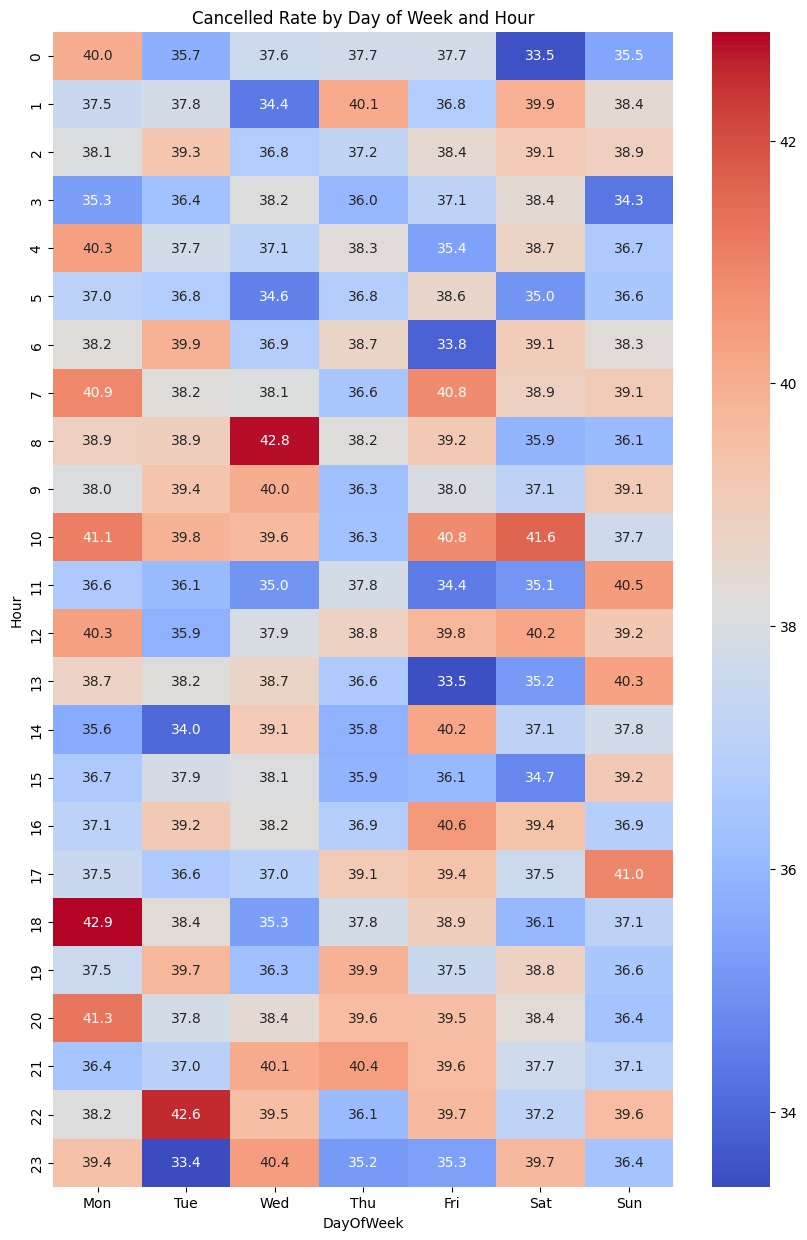

In [79]:
# Cancellation by Hour and Day of Week
time_dof_cancel=data.groupby(['DayOfWeek','Hour']).aggregate({'cancelled': 'mean', 'Booking_ID':'count'}).reset_index()
time_dof_cancel_piv = time_dof_cancel.pivot_table(index= ['Hour'],columns= 'DayOfWeek', values='cancelled')
time_dof_cancel_piv = time_dof_cancel_piv *100
plt.figure(figsize = (10,15))
sns.heatmap(data=time_dof_cancel_piv, cmap='coolwarm', annot=True, fmt='.1f')
plt.title('Cancelled Rate by Day of Week and Hour')
plt.show()

# At 10 AM and 12 AM might hv lower overall success rides.
# Thursday is better and appears consistent on having lower cancellation rate

In [80]:
time_dof_cancel.pivot_table(index= ['Hour'],columns= 'DayOfWeek', values='Booking_ID')

C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\2138524160.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  time_dof_cancel.pivot_table(index= ['Hour'],columns= 'DayOfWeek', values='Booking_ID')


DayOfWeek,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Hour,,,,,,,
0,665.0,708.0,686.0,541.0,583.0,594.0,541.0
1,712.0,691.0,718.0,544.0,544.0,576.0,544.0
2,688.0,728.0,685.0,548.0,528.0,588.0,540.0
3,708.0,718.0,647.0,553.0,504.0,529.0,542.0
4,689.0,681.0,685.0,549.0,557.0,584.0,518.0
5,648.0,726.0,697.0,608.0,500.0,525.0,560.0
6,654.0,722.0,678.0,535.0,606.0,548.0,528.0
7,660.0,756.0,719.0,528.0,556.0,553.0,532.0
8,710.0,696.0,710.0,529.0,549.0,618.0,562.0


C:\Users\Dell\AppData\Local\Temp\ipykernel_4592\3488276201.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.lineplot(data=data.groupby(['Week','DayOfWeek'])['cancelled'].mean().reset_index(), x='DayOfWeek',y='cancelled', hue='Week', marker='o')


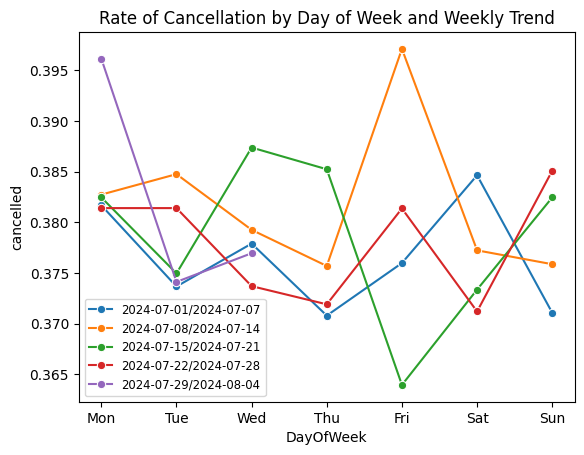

In [81]:
#Green and orange is completely opposite ( week 2 and 3)
#We observe orange trend is similar with red, it is likely the usual trend that supposed to be
#This due to orange is week 2, similar with red week 4, this means week 3 likely have something happened that make the trend differ or sudden change
#
sns.lineplot(data=data.groupby(['Week','DayOfWeek'])['cancelled'].mean().reset_index(), x='DayOfWeek',y='cancelled', hue='Week', marker='o')
plt.title('Rate of Cancellation by Day of Week and Weekly Trend')
plt.legend(fontsize= 'small')
plt.show()

## Investigating Driver Availability

Across driver cancellations, customer cancellations, and incomplete rides,
supply-side factors consistently emerge as a major contributor to unsuccessful bookings.

One of the clearest manifestations of this issue is Driver Not Found outcomes,
which account for 9.83% of all bookings.

Unlike driver cancellations, Driver Not Found cases occur before a ride can even
be matched with a driver. As a result, they may provide useful insight into
potential driver shortages, supply-demand imbalances, or matching inefficiencies.

To explore this further, we examine Driver Not Found rates across pickup
locations and vehicl
e categories.ories.mes.


Additional Observation:
- Driver Not Found rates show some variation across pickup locations, although the differences are relatively moderate.
- The highest rates were observed in Hennur, Marathahalli, Mysore Road, Peenya, and Hosur Road, while Whitefield, Ramamurthy Nagar, Magadi Road, Koramangala, and Hulimavu showed comparatively lower rates.
- This suggests that location may have some influence on driver availability. However, the differences are not large enough to conclude that location alone is the primary driver of Driver Not Found outcomes.
- When comparing vehicle categories, Prime SUV, Prime Plus, and Prime Sedan exhibited slightly higher Driver Not Found rates, while Auto showed the lowest rate.
- However, the differences between vehicle types were relatively small compared to the variation observed across pickup locations. This suggests that Driver Not Found outcomes are more strongly associated with location-based supply constraints than with specific vehicle categories.

**Among repeat customers, are they repeating because they are loyal, or because they got cancelled and had to book again?**

1. We have 94,544 customers
2. We have 7,954 repeat customers
3. 7954 / 94544 ≈ 8.4%
   Only 8.4% of customers are repeat customers
   (quite small proportion)
4. Among repeat customers, 3,653 customers have only successful bookings. This means all orders are successful
5. Among repeat customers, 1,725 customers have only failed bookings. This means all orders are cancelled. This is unusual because they keep coming back despite failures.

   - Are these 1,725 customers repeatedly retrying after failure?
     1. Only 19 customers who retry directly after failure bookings
     2. We found 1071 customers who booked at the same time across multiple dates.
        This suggests:
        - Many unsuccessful customers return at similar times on different days.
        - Could be:
        - commuting pattern
        - recurring demand
        - recurring supply shortage


6. Among 7,954 repeat customers, 3,653 experienced only successful bookings. Meanwhile, 1,725 repeat customers experienced only unsuccessful bookings. However, only a small number of same-day retry attempts were observed, suggesting that most repeated unsuccessful bookings were not immediate retries. Instead, many customers returned on different days, often at similar times, indicating persistent transportation demand despite repeated service failures.



7. There are many customers who repeatedly experience unsuccessful bookings.
Despite these failures, many customers continue returning to the platform
and attempt bookings again on later days.

This suggests:
- There is genuine transportation demand.
- Customers have not completely given up

why are these bookings unsuccessful?

In [66]:
# Driver Not Found
demands=data.pivot_table(index='Pickup_Location', columns='Vehicle_Type', values= 'Booking_ID', aggfunc='count')
driver_not_found= data[data['Booking_Status']=='Driver Not Found'].pivot_table(index='Pickup_Location', columns='Vehicle_Type', values='Booking_ID', aggfunc= 'count')


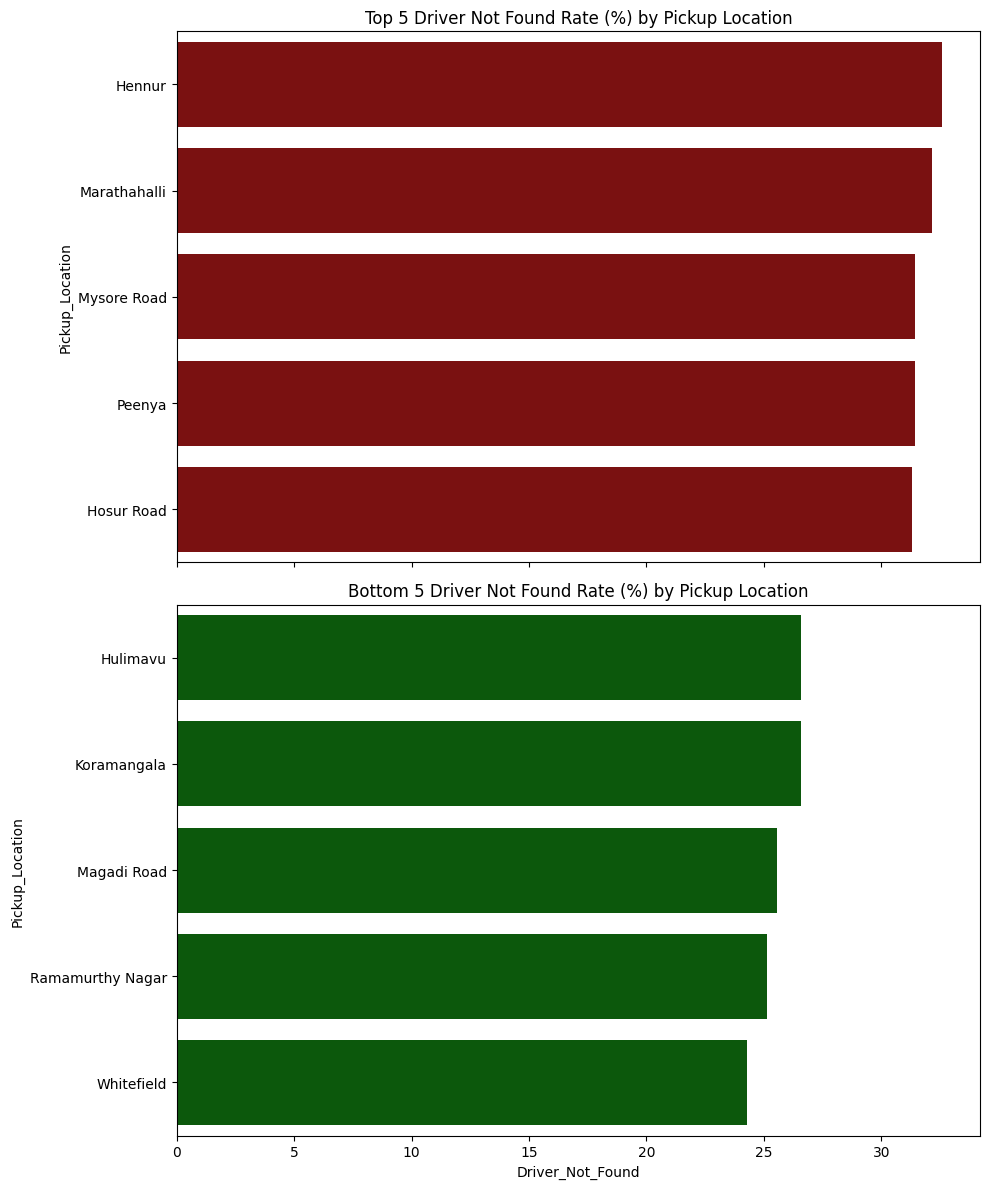

In [67]:
location_driver_not_found= driver_not_found.mean(axis=1).sort_values(ascending=False).reset_index(name='Driver_Not_Found')
fig, ax= plt.subplots(2,1,figsize=(10,12), sharex=True)
sns.barplot(data= location_driver_not_found.head(), y= 'Pickup_Location',x='Driver_Not_Found', ax=ax[0], color='darkred')
ax[0].set_title('Top 5 Driver Not Found Rate (%) by Pickup Location')
sns.barplot(data= location_driver_not_found.tail(), y= 'Pickup_Location',x='Driver_Not_Found', ax=ax[1], color='darkgreen')
ax[1].set_title('Bottom 5 Driver Not Found Rate (%) by Pickup Location')
plt.tight_layout()
plt.show()


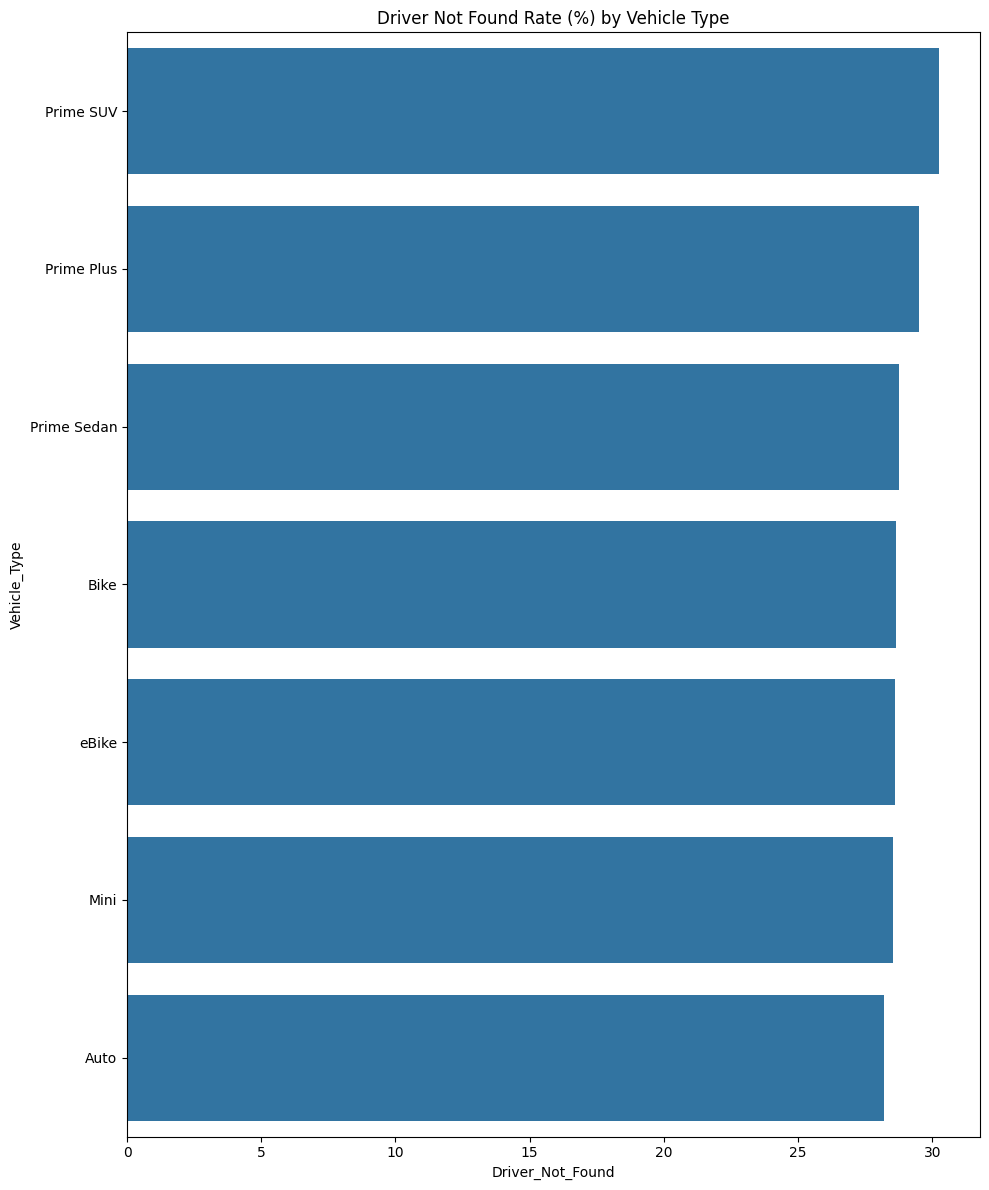

In [68]:
vehicle_driver_not_found= driver_not_found.mean(axis=0).sort_values(ascending=False).reset_index(name='Driver_Not_Found')
plt.subplots(1,1,figsize=(10,12))
sns.barplot(data= vehicle_driver_not_found, y= 'Vehicle_Type',x='Driver_Not_Found')
plt.title('Driver Not Found Rate (%) by Vehicle Type')
plt.tight_layout()
plt.show()


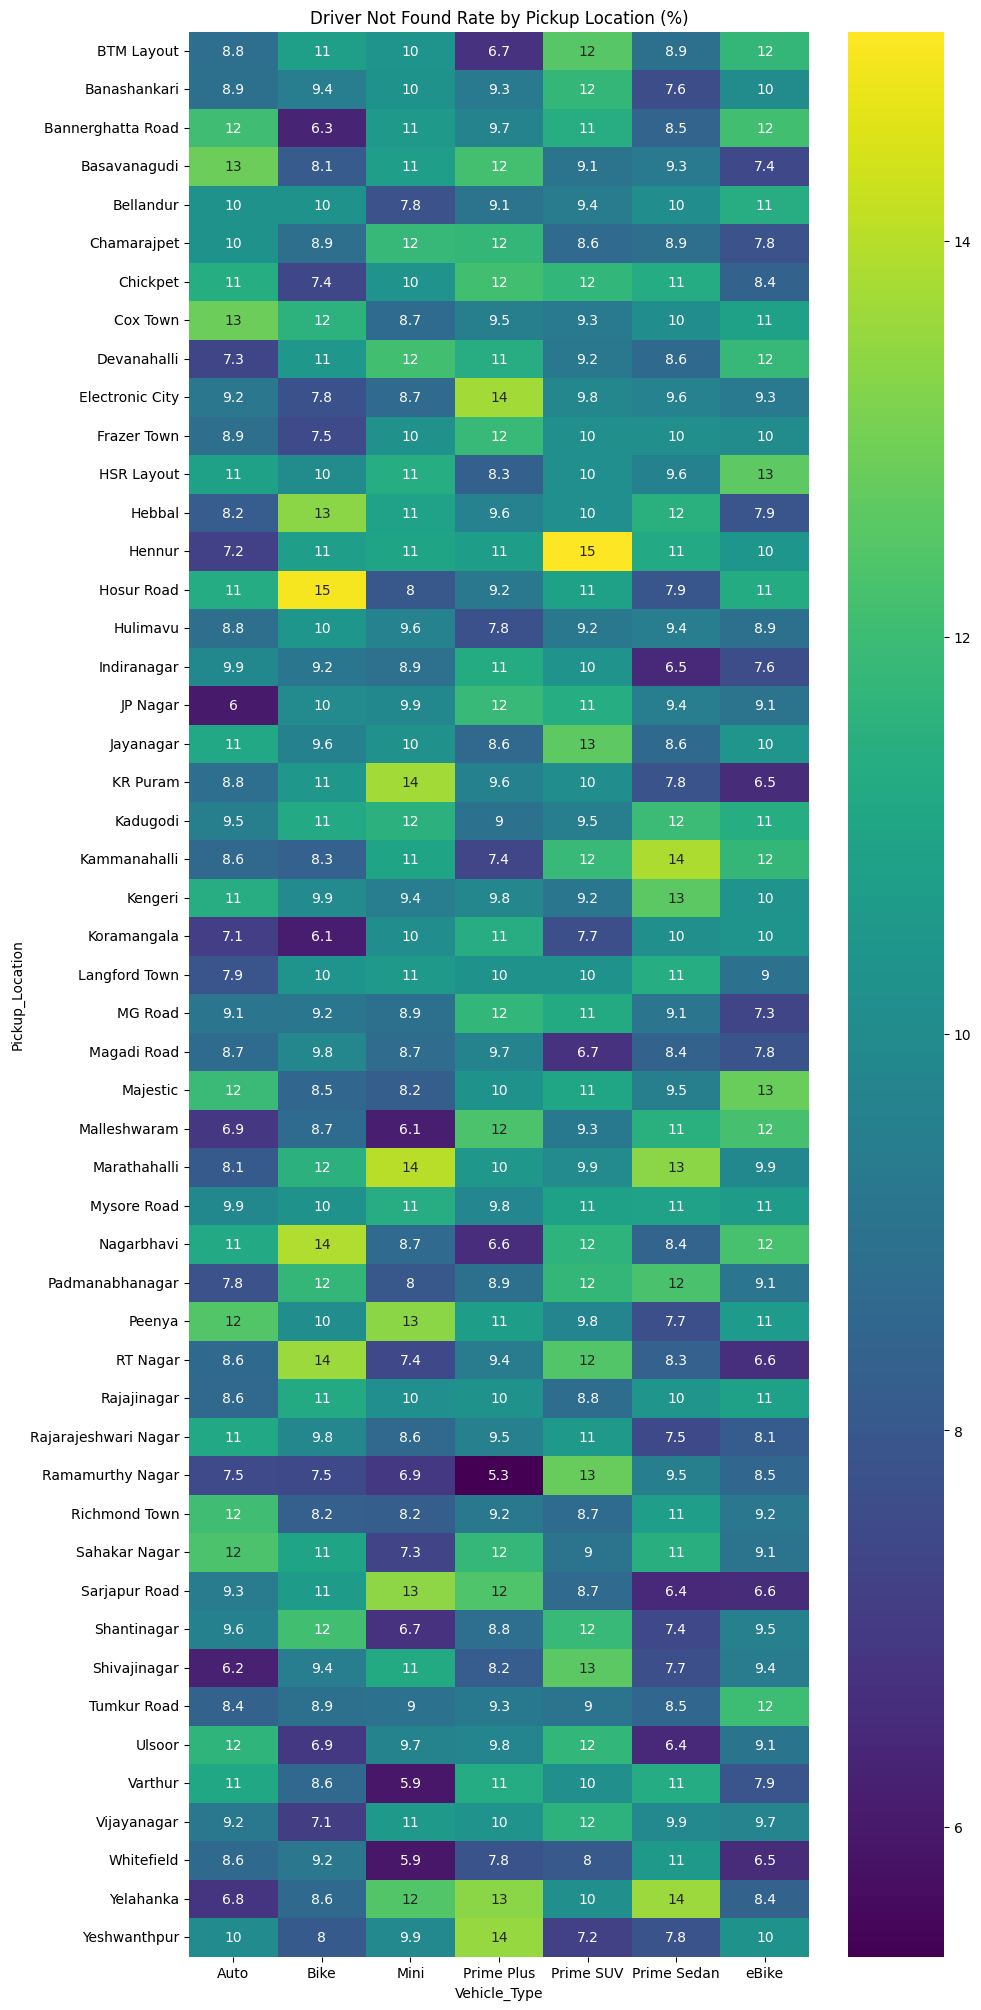

In [69]:
# Driver Not Found
plt.figure(figsize= (10,25))
sns.heatmap(driver_not_found *100/demands, annot=True, cmap='viridis')
plt.title('Driver Not Found Rate by Pickup Location (%)')
plt.show()



# A. Same location affects many vehicles

# Example:
# - Yelahanka → Prime Plus
# - Yelahanka → Mini
# - Yelahanka → Prime Sedan

# other location, e.g. Hennur

# B. Same vehicle bad everywhere

# Example:
# - Prime SUV high rate in many places

# This means vehicle mismatch (low supply / expensive / rejection)